# QDIST v3.1.1 — native-waveform hard-clipping and saturation evidence

**Scientific question.** What fraction of the continuous native task-span
waveform contains intervals whose local plateau morphology and
polarity-specific edge distribution are jointly compatible with hard
clipping or saturation?

QDIST is a sparse event-ledger family, not a scalar quality score. The
three analysis features are reconstructable views of one accepted
clipping-event system: frame prevalence, episode rate, and channel-sample
burden. They are not independent measurements of three nonlinear
mechanisms.

The claim is deliberately narrow. QDIST does **not** estimate total
harmonic distortion, intermodulation distortion, soft clipping,
dynamic-range compression, limiting, automatic gain control, general codec
distortion, or perceptual distortion. Absence of detected hard-clipping
morphology does not prove that no upstream nonlinear processing occurred.

The authoritative implementation is `paper1_qc.qdist`. This notebook never
redefines the detector. It validates the signal-view contract, formulas,
exact ledger reconstruction, hard-clip dose recovery, quantization and
natural-extrema false-positive behavior, post-clipping attenuation,
resampling/codec effects, parameter stability, sparse-event cohort behavior,
and a label-blind accepted/rejected-event gallery. Clinical labels and human
QC annotations are not used to tune or approve the measurement.


**Final detector operating rule.** Candidate generation uses a permissive recording-relative floor. Acceptance requires either a strong recording-edge level or extensive repeated lower-level edge support, together with local prominence and the full morphology/terminality contract. This two-tier rule preserves severe low-gain saturation while rejecting isolated quantized natural extrema.

## 0. Environment, controls, and common output contract


In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
from tempfile import TemporaryDirectory
import gc
import gzip
import hashlib
import json
import math
import pickle
import shutil
import subprocess
import sys
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal, stats
from IPython.display import Markdown, display
import yaml


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (
            (candidate / "pyproject.toml").exists()
            and (candidate / "src" / "paper1_qc").exists()
        ):
            return candidate
    raise FileNotFoundError("Open this notebook from inside the paper_1 repository.")


ROOT = find_project_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from paper1_qc.feature_validation import (
    OKABE_ITO,
    ValidationCheck,
    gate_passed,
    save_publication_figure,
    save_table_bundle,
    set_publication_style,
    sha256_file,
    validation_frame,
    write_json,
)
from paper1_qc.media import decode_native_audio
from paper1_qc.qdist import (
    ANALYSIS_FEATURES,
    DEFAULT_PARAMETERS,
    FEATURE_DEFINITIONS,
    MEASUREMENT_VERSION,
    NativeSignalProvenance,
    PRIMARY_FEATURES,
    SECONDARY_FEATURES,
    TimeInterval,
    apply_hard_clip,
    apply_soft_clip,
    extract_qdist,
    feature_registry_frame,
    quantize_pcm,
    reconstruct_qdist_features,
)

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 260)
pd.set_option("display.width", 260)
set_publication_style()

CONFIG = ROOT / "config" / "project.yaml"
MAIN_OUTPUTS = ROOT / "MAIN outputs"
STAGE = ROOT / "outputs" / "02_features" / "nonlinear_distortion" / MEASUREMENT_VERSION
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
GALLERY = STAGE / "gallery"
AUDIT = STAGE / "audit"
CHECKPOINTS = AUDIT / "recording_checkpoints"
for directory in [TABLES, FIGURES, GALLERY, AUDIT, CHECKPOINTS]:
    directory.mkdir(parents=True, exist_ok=True)

RUN_COHORT_EXTRACTION = True
RUN_CODEC_CHARACTERIZATION = True
RUN_EMPIRICAL_ROBUSTNESS = True
RUN_PACKAGE_TESTS = True
PACKAGE_TESTS_CONFIRMED = False
RESUME_FROM_CHECKPOINTS = True
BUILD_GALLERY = True

# Runtime controls. Every default positive recording is always included in the
# robustness audit; this number controls only the label-blind valid-zero sample.
MAX_ROBUSTNESS_ZERO_RECORDINGS = 40
MAX_REJECTED_REVIEW_ITEMS = 20
MAX_VALID_ZERO_REVIEW_ITEMS = 10
PROGRESS_EVERY = 25
CHECKPOINT_COMPRESSION_LEVEL = 3

# The first complete v3.1.1 run is a candidate. Change these only after every
# blocking gate and the versioned event-review template have been completed.
PUBLISH_AND_FREEZE_QDIST_V311 = False
PACKAGE_INTEGRATION_APPROVED = False
QDIST_REVIEW_DECISION = "PENDING"
QDIST_REVIEWER = ""
QDIST_REVIEW_RATIONALE = ""

PARAMETERS = DEFAULT_PARAMETERS
RNG = np.random.default_rng(PARAMETERS.random_seed)

print("Project:", ROOT)
print("Measurement:", MEASUREMENT_VERSION)
print("Parameter hash:", PARAMETERS.parameter_hash())
print("Cohort extraction:", RUN_COHORT_EXTRACTION)
print("Empirical robustness:", RUN_EMPIRICAL_ROBUSTNESS)
print("Outputs:", STAGE)


Project: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1
Measurement: qdist-v3.1.1
Parameter hash: 7802da72a6654f744fd4f5d7d53f7f1efe62356c043ecc557f4219ab44649e28
Cohort extraction: True
Empirical robustness: True
Outputs: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\nonlinear_distortion\qdist-v3.1.1


## 1. Immutable feature registry, parameters, and legacy disposition


In [2]:
feature_registry = feature_registry_frame()
parameter_table = pd.DataFrame([
    {
        "parameter": key,
        "value": json.dumps(value) if isinstance(value, (list, dict)) else value,
    }
    for key, value in PARAMETERS.to_dict().items()
])
legacy_crosswalk = pd.DataFrame([
    {
        "legacy_output": "qdist_hard_clip_sample_fraction",
        "v3_1_output": "qdist_hard_clipped_sample_fraction",
        "disposition": "redesigned_and_renamed",
        "reason": "native continuous task span; multichannel channel-sample denominator; accepted plateau ledger",
    },
    {
        "legacy_output": "qdist_clip_event_rate_per_min",
        "v3_1_output": "qdist_hard_clip_event_rate_per_min",
        "disposition": "redesigned_and_renamed",
        "reason": "merged episode ledger and finite native exposure replace concatenated speech clips",
    },
    {
        "legacy_output": "qdist_clipped_frame_fraction",
        "v3_1_output": "qdist_hard_clipped_frame_fraction",
        "disposition": "redesigned_and_renamed",
        "reason": "non-overlapping native task-span frames intersect accepted plateaus on any channel",
    },
    {
        "legacy_output": "qdist_near_fullscale_fraction",
        "v3_1_output": "diagnostic_only",
        "disposition": "removed_from_analysis_set",
        "reason": "high digital headroom use is not clipping and clipping can persist below full scale after attenuation",
    },
    {
        "legacy_output": "qdist_edge_histogram_spike",
        "v3_1_output": "diagnostic_only edge-ledger fields",
        "disposition": "removed_from_analysis_set",
        "reason": "edge concentration alone is insufficient without local plateau morphology and terminality",
    },
])
save_table_bundle(feature_registry, TABLES, "qdist_v311_feature_registry")
save_table_bundle(parameter_table, TABLES, "qdist_v311_parameters")
save_table_bundle(legacy_crosswalk, TABLES, "qdist_v311_legacy_crosswalk")
write_json(PARAMETERS.to_dict(), AUDIT / "qdist_v311_parameters.json")

forbidden = "thd|soft|compression|limiter|agc|perceptual|composite|score"
registry_checks = validation_frame([
    ValidationCheck(
        "G1 registry", "exactly three prespecified analysis features",
        tuple(feature_registry["name"]) == tuple(ANALYSIS_FEATURES),
        str(feature_registry["name"].tolist()), str(list(ANALYSIS_FEATURES)),
        "repair qdist registry/package mismatch",
    ),
    ValidationCheck(
        "G1 registry", "no broad nonlinear-distortion or scalar-score output",
        not feature_registry["name"].str.contains(forbidden, case=False, regex=True).any(),
        "absent", "absent", "remove unsupported construct claim",
    ),
    ValidationCheck(
        "G1 registry", "three outputs identify their reconstructing ledgers",
        feature_registry["source_ledger"].notna().all(),
        str(feature_registry["source_ledger"].tolist()), "all explicit",
        "repair ledger contract",
    ),
    ValidationCheck(
        "G1 registry", "near-full-scale and histogram-spike legacy outputs are not analysis features",
        not any("near_fullscale" in name or "histogram" in name for name in ANALYSIS_FEATURES),
        str(list(ANALYSIS_FEATURES)), "diagnostic only", "repair analysis feature list",
    ),
])
display(feature_registry)
display(legacy_crosswalk)
display(registry_checks)
if not gate_passed(registry_checks):
    raise RuntimeError("QDIST registry contract failed.")


,name,display_name,subdomain,role,unit,maturity,estimand,orientation,claim_boundary,minimum_support,known_confounds,source_ledger,supporting_references
0,qdist_hard_clipped_frame_fraction,Hard-clipped frame fraction,time-localized clipping prevalence,primary,"fraction [0,1]",literature-informed engineering detector; stud...,Fraction of non-overlapping native task-span f...,Higher indicates a larger fraction of task-spa...,Hard-clipping/saturation evidence only; not to...,At least 3 s finite task-span exposure and 100...,"Quantization, naturally flat extrema, square-l...",accepted plateau ledger,Li et al. (2014); Patel et al. (2018); Goldsac...
1,qdist_hard_clip_event_rate_per_min,Hard-clipping episode rate,clipping episode frequency,primary event metric,events/min,literature-informed engineering detector; stud...,Number of merged accepted clipping episodes pe...,Higher indicates more distinct accepted clippi...,Episode grouping depends on the frozen merge r...,At least 3 s finite task-span exposure; event ...,"Merge-gap choice, fragmented codec-smeared pla...",merged episode ledger,Li et al. (2014); Patel et al. (2018); Goldsac...
2,qdist_hard_clipped_sample_fraction,Hard-clipped channel-sample fraction,clipped waveform burden,secondary,"fraction [0,1]",literature-informed engineering detector; stud...,Fraction of finite eligible native channel-sam...,Higher indicates greater accepted plateau supp...,"Channel-sample burden, not affected-time fract...",At least 3 s finite task-span exposure and fin...,"Channel count, quantization, codec smearing, a...",accepted plateau ledger,Li et al. (2014); Patel et al. (2018); Goldsac...


,legacy_output,v3_1_output,disposition,reason
0,qdist_hard_clip_sample_fraction,qdist_hard_clipped_sample_fraction,redesigned_and_renamed,native continuous task span; multichannel chan...
1,qdist_clip_event_rate_per_min,qdist_hard_clip_event_rate_per_min,redesigned_and_renamed,merged episode ledger and finite native exposu...
2,qdist_clipped_frame_fraction,qdist_hard_clipped_frame_fraction,redesigned_and_renamed,non-overlapping native task-span frames inters...
3,qdist_near_fullscale_fraction,diagnostic_only,removed_from_analysis_set,high digital headroom use is not clipping and ...
4,qdist_edge_histogram_spike,diagnostic_only edge-ledger fields,removed_from_analysis_set,edge concentration alone is insufficient witho...


,layer,check,passed,observed,required,action_if_failed,blocking
0,G1 registry,exactly three prespecified analysis features,True,"['qdist_hard_clipped_frame_fraction', 'qdist_h...","['qdist_hard_clipped_frame_fraction', 'qdist_h...",repair qdist registry/package mismatch,True
1,G1 registry,no broad nonlinear-distortion or scalar-score ...,True,absent,absent,remove unsupported construct claim,True
2,G1 registry,three outputs identify their reconstructing le...,True,"['accepted plateau ledger', 'merged episode le...",all explicit,repair ledger contract,True
3,G1 registry,near-full-scale and histogram-spike legacy out...,True,"['qdist_hard_clipped_frame_fraction', 'qdist_h...",diagnostic only,repair analysis feature list,True


## 2. Deterministic formula, provenance, and invariance controls


In [3]:
def speech_like_carrier(fs=16_000, duration_sec=5.0, seed=31):
    rng = np.random.default_rng(seed)
    time = np.arange(round(fs * duration_sec)) / fs
    f0 = 135.0 + 18.0 * np.sin(2 * np.pi * 0.37 * time)
    phase = 2 * np.pi * np.cumsum(f0) / fs
    source = (
        0.62 * np.sin(phase)
        + 0.24 * np.sin(2 * phase + 0.2)
        + 0.12 * np.sin(3 * phase - 0.4)
    )
    envelope = 0.40 + 0.55 * np.square(np.sin(2 * np.pi * 0.72 * time))
    waveform = envelope * source + 0.004 * rng.standard_normal(len(time))
    waveform /= max(np.max(np.abs(waveform)), 1e-12)
    return 0.86 * waveform


def hard_clip_bursts(waveform, fs, bursts, limit):
    output = np.asarray(waveform, dtype=float).copy()
    for start_sec, end_sec in bursts:
        left, right = round(start_sec * fs), round(end_sec * fs)
        output[left:right] = apply_hard_clip(output[left:right], limit)
    return output


FS_SYNTH = 16_000
clean = speech_like_carrier(FS_SYNTH)
clipped = hard_clip_bursts(clean, FS_SYNTH, [(1.0, 2.0)], 0.42)
base = extract_qdist(clipped, FS_SYNTH, logical_recording_id="base")
inverted = extract_qdist(-clipped, FS_SYNTH, logical_recording_id="inverted")
attenuated = extract_qdist(0.25 * clipped, FS_SYNTH, logical_recording_id="attenuated")
clean_result = extract_qdist(clean, FS_SYNTH, logical_recording_id="clean")
soft_result = extract_qdist(apply_soft_clip(clean, 3.0), FS_SYNTH, logical_recording_id="soft")
stereo = extract_qdist(
    np.column_stack([clipped, clean]), FS_SYNTH, logical_recording_id="stereo"
)

reconstructed = reconstruct_qdist_features(
    base.accepted_plateau_ledger,
    base.episode_ledger,
    finite_channel_sample_count=base.recording["qdist_finite_channel_sample_count"],
    finite_time_sample_count=base.recording["qdist_finite_time_sample_count"],
    finite_exposure_sec=base.recording["qdist_finite_exposure_sec"],
    frame_length_samples=base.recording["qdist_frame_length_samples"],
    complete_frame_count=base.recording["qdist_complete_frame_count"],
)
formula_rows = []
for feature in ANALYSIS_FEATURES:
    formula_rows.append({
        "feature": feature,
        "stored": base.recording[feature],
        "reconstructed": reconstructed[feature],
        "absolute_difference": abs(base.recording[feature] - reconstructed[feature]),
        "inverted": inverted.recording[feature],
        "attenuated_below_full_scale": attenuated.recording[feature],
        "stereo_one_channel": stereo.recording[feature],
    })
formula_table = pd.DataFrame(formula_rows)
save_table_bundle(formula_table, TABLES, "qdist_v311_formula_reconstruction")

formula_checks = validation_frame([
    ValidationCheck(
        "G2 formula", "all three features reconstruct exactly from ledgers",
        formula_table["absolute_difference"].max() <= 1e-15,
        f"max difference={formula_table['absolute_difference'].max():.3g}", "<=1e-15",
        "repair interval/denominator logic",
    ),
    ValidationCheck(
        "G3 invariance", "polarity inversion preserves analysis outputs",
        all(np.isclose(base.recording[f], inverted.recording[f], rtol=1e-12, atol=1e-15) for f in ANALYSIS_FEATURES),
        "preserved", "preserved", "repair polarity-specific logic",
    ),
    ValidationCheck(
        "G3 invariance", "post-clipping attenuation preserves morphology below full scale",
        all(np.isclose(base.recording[f], attenuated.recording[f], rtol=1e-12, atol=1e-15) for f in ANALYSIS_FEATURES)
        and attenuated.recording["qdist_near_fullscale_channel_sample_fraction"] == 0,
        "preserved with near-full-scale diagnostic=0", "preserved",
        "remove full-scale dependence",
    ),
    ValidationCheck(
        "G5 discriminant", "clean speech-like carrier is an available zero",
        clean_result.recording["qdist_status"] == "available_no_events",
        clean_result.recording["qdist_status"], "available_no_events",
        "repair false-positive behavior",
    ),
    ValidationCheck(
        "scope", "soft clipping is not forced positive",
        soft_result.recording["qdist_hard_clip_event_count"] == 0,
        str(soft_result.recording["qdist_hard_clip_event_count"]), "0",
        "repair claim boundary or detector",
    ),
    ValidationCheck(
        "multichannel", "channel-sample burden is not max-channel aggregation",
        np.isclose(
            stereo.recording["qdist_hard_clipped_sample_fraction"],
            0.5 * base.recording["qdist_hard_clipped_sample_fraction"],
            rtol=1e-12,
        ),
        str(stereo.recording["qdist_hard_clipped_sample_fraction"]),
        "half mono burden when one of two channels clips",
        "repair multichannel denominator",
    ),
])
display(formula_table)
display(formula_checks)
save_table_bundle(formula_checks, TABLES, "qdist_v311_formula_checks")


,feature,stored,reconstructed,absolute_difference,inverted,attenuated_below_full_scale,stereo_one_channel
0,qdist_hard_clipped_frame_fraction,0.174699,0.174699,0.0,0.174699,0.174699,0.174699
1,qdist_hard_clip_event_rate_per_min,24.000000,24.000000,0.0,24.000000,24.000000,24.000000
2,qdist_hard_clipped_sample_fraction,0.062750,0.062750,0.0,0.062750,0.062750,0.031375


,layer,check,passed,observed,required,action_if_failed,blocking
0,G2 formula,all three features reconstruct exactly from le...,True,max difference=0,<=1e-15,repair interval/denominator logic,True
1,G3 invariance,polarity inversion preserves analysis outputs,True,preserved,preserved,repair polarity-specific logic,True
2,G3 invariance,post-clipping attenuation preserves morphology...,True,preserved with near-full-scale diagnostic=0,preserved,remove full-scale dependence,True
3,G5 discriminant,clean speech-like carrier is an available zero,True,available_no_events,available_no_events,repair false-positive behavior,True
4,scope,soft clipping is not forced positive,True,0,0,repair claim boundary or detector,True
5,multichannel,channel-sample burden is not max-channel aggre...,True,0.031375,half mono burden when one of two channels clips,repair multichannel denominator,True


{'csv': WindowsPath('C:/Users/musikicn/Desktop/Nevena_project/Paper_1/paper_1/outputs/02_features/nonlinear_distortion/qdist-v3.1.1/tables/qdist_v311_formula_checks.csv'),
 'parquet': WindowsPath('C:/Users/musikicn/Desktop/Nevena_project/Paper_1/paper_1/outputs/02_features/nonlinear_distortion/qdist-v3.1.1/tables/qdist_v311_formula_checks.parquet')}

## 3. Hard-clipping construct recovery and sample-accurate dose ordering

The injection window is selected without detector output by maximizing carrier
support above the mildest prespecified clipping limit. This prevents an
apparently injected grid cell from containing zero true clipped samples. Each
condition retains its exact sample-level truth mask, permitting precision,
recall, F1, onset/offset error, and burden-recovery assessment rather than only
checking whether at least one event was found.


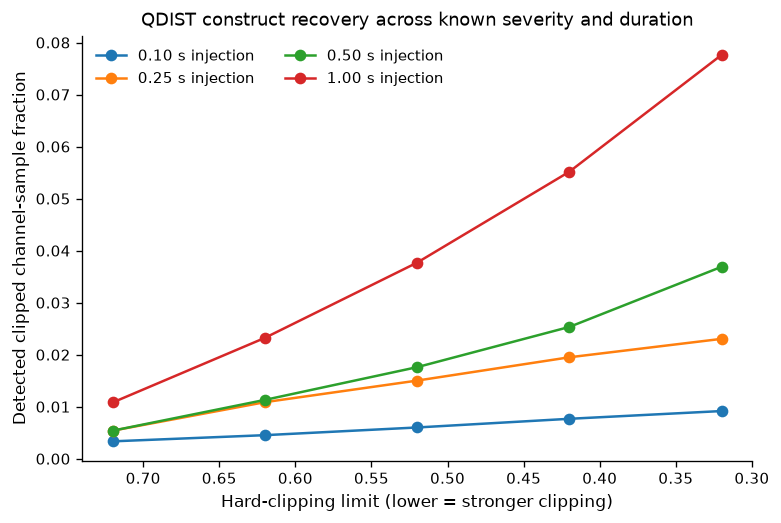

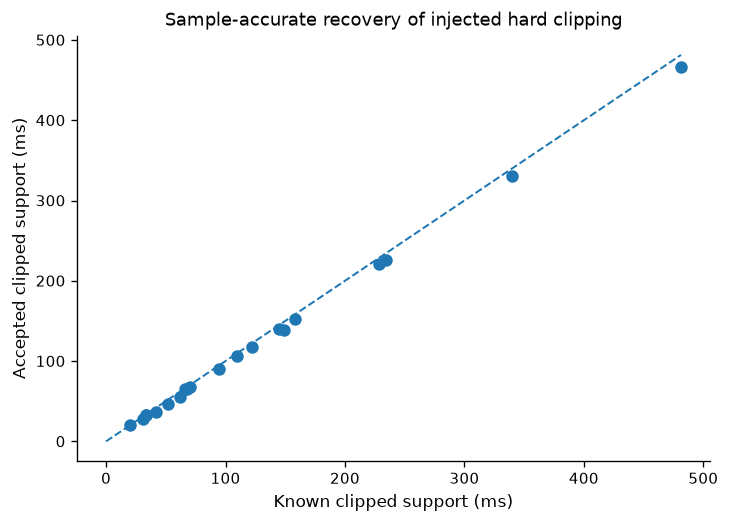

,duration_sec,clip_limit,injection_start_sec,injection_end_sec,anchor_truth_sample_count_at_0_72,true_clipped_sample_count,predicted_clipped_sample_count,true_positive_sample_count,false_positive_sample_count,false_negative_sample_count,sample_precision,sample_recall,sample_f1,onset_error_samples,offset_error_samples,true_clipped_duration_ms,detected_clipped_duration_ms,absolute_duration_error_ms,injected_clipped_sample_fraction,detected_frame_fraction,detected_event_rate_per_min,detected_sample_fraction,accepted_plateau_count,event_count,status
0,0.10,0.72,3.762625,3.862625,322,322,323,322,1,0,0.996904,1.000000,0.998450,0,0,20.1250,20.1875,0.0625,0.003354,0.020,10.0,0.003365,30,1,available_events
1,0.10,0.62,3.762625,3.862625,322,498,437,437,0,61,1.000000,0.877510,0.934759,33,-109,31.1250,27.3125,3.8125,0.005188,0.020,10.0,0.004552,26,1,available_events
2,0.10,0.52,3.762625,3.862625,322,665,579,578,1,87,0.998273,0.869173,0.929260,36,-106,41.5625,36.1875,5.3750,0.006927,0.020,10.0,0.006031,26,1,available_events
3,0.10,0.42,3.762625,3.862625,322,835,739,739,0,96,1.000000,0.885030,0.939009,102,-103,52.1875,46.1875,6.0000,0.008698,0.020,10.0,0.007698,26,1,available_events
4,0.10,0.32,3.762625,3.862625,322,992,882,882,0,110,1.000000,0.889113,0.941302,97,-99,62.0000,55.1250,6.8750,0.010333,0.020,10.0,0.009187,26,1,available_events
5,0.25,0.72,3.690187,3.940187,533,533,520,519,1,14,0.998077,0.973734,0.985755,107,-113,33.3125,32.5000,0.8125,0.005552,0.045,10.0,0.005417,55,1,available_events
6,0.25,0.62,3.690187,3.940187,533,1079,1046,1046,0,33,1.000000,0.969416,0.984471,0,-109,67.4375,65.3750,2.0625,0.011240,0.045,10.0,0.010896,70,1,available_events
7,0.25,0.52,3.690187,3.940187,533,1513,1444,1443,1,70,0.999307,0.953734,0.975989,74,-105,94.5625,90.2500,4.3125,0.015760,0.045,10.0,0.015042,69,1,available_events
8,0.25,0.42,3.690187,3.940187,533,1961,1874,1873,1,88,0.999466,0.955125,0.976793,71,-102,122.5625,117.1250,5.4375,0.020427,0.045,10.0,0.019521,69,1,available_events
9,0.25,0.32,3.690187,3.940187,533,2384,2214,2214,0,170,1.000000,0.928691,0.963027,106,-99,149.0000,138.3750,10.6250,0.024833,0.045,10.0,0.023062,67,1,available_events


,layer,check,passed,observed,required,action_if_failed,blocking
0,G4 construct,every grid cell contains nonzero known clippin...,True,minimum truth samples=322,>0 in every cell,repair injection-window selection,True
1,G4 construct,every injected condition is detected,True,detected=20/20,all conditions,repair sensitivity to known hard clipping,True
2,G4 recovery,sample-level precision is at least 0.99 in eve...,True,minimum=0.9969,>=0.99,repair false-positive plateau acceptance,True
3,G4 recovery,sample-level recall is at least 0.85 in every ...,True,minimum=0.8692,>=0.85,repair plateau boundary/support recovery,True
4,G4 recovery,sample-level F1 is at least 0.90 in every cond...,True,minimum=0.9293,>=0.90,repair precision-recall operating point,True
5,G4 construct,sample burden is monotonic with clipping severity,True,"[True, True, True, True]",all True,repair edge/plateau acceptance,True
6,G4 construct,detected burden tracks known clipped support,True,Spearman rho=0.998,>=0.85,repair burden recovery,True


In [4]:
dose_rows = []
carrier = speech_like_carrier(FS_SYNTH, duration_sec=6.0, seed=71)


def highest_energy_window(waveform, fs, duration_sec, *, anchor_threshold=0.72, margin_sec=0.25):
    """Return a deterministic high-energy window with known clip exposure.

    The v3.1.0 grid inserted clipping at a fixed clock time. Some carrier
    windows never exceeded the requested clip limit, so those cells contained
    no true clipping despite being labelled as injected conditions. Here the
    window is selected independently of detector output by maximizing the
    number of carrier samples above the mildest prespecified clip limit.
    """
    window_samples = max(1, int(round(duration_sec * fs)))
    above = (np.abs(np.asarray(waveform, dtype=float)) > anchor_threshold).astype(np.int64)
    cumulative = np.concatenate([[0], np.cumsum(above)])
    counts = cumulative[window_samples:] - cumulative[:-window_samples]
    left_bound = min(int(round(margin_sec * fs)), max(len(counts) - 1, 0))
    right_bound = max(left_bound + 1, len(counts) - int(round(margin_sec * fs)))
    search = counts[left_bound:right_bound]
    start = left_bound + int(np.argmax(search))
    return start, start + window_samples, int(counts[start])


def accepted_sample_mask(extraction, sample_count):
    mask = np.zeros(int(sample_count), dtype=bool)
    for row in extraction.accepted_plateau_ledger.itertuples(index=False):
        left = max(0, int(row.start_sample_task))
        right = min(int(sample_count), int(row.end_sample_task_exclusive))
        if right > left:
            mask[left:right] = True
    return mask


for duration_sec in [0.10, 0.25, 0.50, 1.00]:
    left, right, anchor_truth_count = highest_energy_window(
        carrier, FS_SYNTH, duration_sec, anchor_threshold=0.72
    )
    start_sec = left / FS_SYNTH
    end_sec = right / FS_SYNTH
    for clip_limit in [0.72, 0.62, 0.52, 0.42, 0.32]:
        transformed = hard_clip_bursts(
            carrier, FS_SYNTH,
            [(start_sec, end_sec)],
            clip_limit,
        )
        extraction = extract_qdist(
            transformed, FS_SYNTH,
            logical_recording_id=f"d{duration_sec}_l{clip_limit}",
        )

        true_mask = np.zeros(len(carrier), dtype=bool)
        true_mask[left:right] = np.abs(carrier[left:right]) > clip_limit
        predicted_mask = accepted_sample_mask(extraction, len(carrier))
        true_positive = int(np.sum(true_mask & predicted_mask))
        false_positive = int(np.sum(~true_mask & predicted_mask))
        false_negative = int(np.sum(true_mask & ~predicted_mask))
        true_count = int(true_mask.sum())
        predicted_count = int(predicted_mask.sum())
        sample_precision = (
            true_positive / (true_positive + false_positive)
            if true_positive + false_positive else np.nan
        )
        sample_recall = (
            true_positive / (true_positive + false_negative)
            if true_positive + false_negative else np.nan
        )
        sample_f1 = (
            2.0 * sample_precision * sample_recall / (sample_precision + sample_recall)
            if np.isfinite(sample_precision + sample_recall) and sample_precision + sample_recall > 0
            else np.nan
        )
        true_indices = np.flatnonzero(true_mask)
        predicted_indices = np.flatnonzero(predicted_mask)
        onset_error_samples = (
            int(predicted_indices[0] - true_indices[0])
            if true_indices.size and predicted_indices.size else np.nan
        )
        offset_error_samples = (
            int(predicted_indices[-1] - true_indices[-1])
            if true_indices.size and predicted_indices.size else np.nan
        )
        dose_rows.append({
            "duration_sec": duration_sec,
            "clip_limit": clip_limit,
            "injection_start_sec": start_sec,
            "injection_end_sec": end_sec,
            "anchor_truth_sample_count_at_0_72": anchor_truth_count,
            "true_clipped_sample_count": true_count,
            "predicted_clipped_sample_count": predicted_count,
            "true_positive_sample_count": true_positive,
            "false_positive_sample_count": false_positive,
            "false_negative_sample_count": false_negative,
            "sample_precision": sample_precision,
            "sample_recall": sample_recall,
            "sample_f1": sample_f1,
            "onset_error_samples": onset_error_samples,
            "offset_error_samples": offset_error_samples,
            "true_clipped_duration_ms": 1000.0 * true_count / FS_SYNTH,
            "detected_clipped_duration_ms": 1000.0 * predicted_count / FS_SYNTH,
            "absolute_duration_error_ms": 1000.0 * abs(predicted_count - true_count) / FS_SYNTH,
            "injected_clipped_sample_fraction": true_mask.mean(),
            "detected_frame_fraction": extraction.recording["qdist_hard_clipped_frame_fraction"],
            "detected_event_rate_per_min": extraction.recording["qdist_hard_clip_event_rate_per_min"],
            "detected_sample_fraction": extraction.recording["qdist_hard_clipped_sample_fraction"],
            "accepted_plateau_count": extraction.recording["qdist_accepted_plateau_count"],
            "event_count": extraction.recording["qdist_hard_clip_event_count"],
            "status": extraction.recording["qdist_status"],
        })

dose_table = pd.DataFrame(dose_rows)
save_table_bundle(dose_table, TABLES, "qdist_v311_hard_clip_dose_grid")

monotonic_groups = []
for duration, local in dose_table.groupby("duration_sec"):
    ordered = local.sort_values("clip_limit", ascending=False)
    # As the clipping limit falls, true and detected burden should not decrease.
    monotonic_groups.append(bool(
        np.all(np.diff(ordered["detected_sample_fraction"].to_numpy(float)) >= -1e-12)
    ))

burden_rho = dose_table[
    ["injected_clipped_sample_fraction", "detected_sample_fraction"]
].corr(method="spearman").iloc[0, 1]
mechanism_checks = validation_frame([
    ValidationCheck(
        "G4 construct", "every grid cell contains nonzero known clipping truth",
        dose_table["true_clipped_sample_count"].gt(0).all(),
        f"minimum truth samples={int(dose_table['true_clipped_sample_count'].min())}",
        ">0 in every cell", "repair injection-window selection",
    ),
    ValidationCheck(
        "G4 construct", "every injected condition is detected",
        dose_table["event_count"].gt(0).all(),
        f"detected={int(dose_table['event_count'].gt(0).sum())}/{len(dose_table)}",
        "all conditions", "repair sensitivity to known hard clipping",
    ),
    ValidationCheck(
        "G4 recovery", "sample-level precision is at least 0.99 in every condition",
        dose_table["sample_precision"].min() >= 0.99,
        f"minimum={dose_table['sample_precision'].min():.4f}", ">=0.99",
        "repair false-positive plateau acceptance",
    ),
    ValidationCheck(
        "G4 recovery", "sample-level recall is at least 0.85 in every condition",
        dose_table["sample_recall"].min() >= 0.85,
        f"minimum={dose_table['sample_recall'].min():.4f}", ">=0.85",
        "repair plateau boundary/support recovery",
    ),
    ValidationCheck(
        "G4 recovery", "sample-level F1 is at least 0.90 in every condition",
        dose_table["sample_f1"].min() >= 0.90,
        f"minimum={dose_table['sample_f1'].min():.4f}", ">=0.90",
        "repair precision-recall operating point",
    ),
    ValidationCheck(
        "G4 construct", "sample burden is monotonic with clipping severity",
        all(monotonic_groups), str(monotonic_groups), "all True",
        "repair edge/plateau acceptance",
    ),
    ValidationCheck(
        "G4 construct", "detected burden tracks known clipped support",
        burden_rho >= 0.85,
        f"Spearman rho={burden_rho:.3f}", ">=0.85",
        "repair burden recovery",
    ),
])
save_table_bundle(mechanism_checks, TABLES, "qdist_v311_mechanism_checks")

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for duration, local in dose_table.groupby("duration_sec"):
    ordered = local.sort_values("clip_limit", ascending=False)
    ax.plot(
        ordered["clip_limit"], ordered["detected_sample_fraction"],
        marker="o", label=f"{duration:.2f} s injection",
    )
ax.invert_xaxis()
ax.set_xlabel("Hard-clipping limit (lower = stronger clipping)")
ax.set_ylabel("Detected clipped channel-sample fraction")
ax.set_title("QDIST construct recovery across known severity and duration")
ax.legend(frameon=False, ncol=2)
save_publication_figure(
    fig, FIGURES, "qdist_v311_hard_clip_dose_response",
    caption=(
        "Detected QDIST sample burden across prespecified hard-clipping limits and "
        "high-energy injection durations. Every condition contains nonzero sample-level truth."
    ),
    alt_text="Line plot showing greater detected sample burden for stronger and longer hard clipping.",
)
plt.show()

fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.scatter(
    dose_table["true_clipped_duration_ms"],
    dose_table["detected_clipped_duration_ms"],
    s=42,
)
maximum_duration = float(max(
    dose_table["true_clipped_duration_ms"].max(),
    dose_table["detected_clipped_duration_ms"].max(),
))
ax.plot([0, maximum_duration], [0, maximum_duration], linestyle="--", linewidth=1.2)
ax.set_xlabel("Known clipped support (ms)")
ax.set_ylabel("Accepted clipped support (ms)")
ax.set_title("Sample-accurate recovery of injected hard clipping")
save_publication_figure(
    fig, FIGURES, "qdist_v311_hard_clip_sample_recovery",
    caption=(
        "Accepted clipped support versus known sample-level clipping support. "
        "The dashed line marks exact recovery."
    ),
    alt_text="Scatter plot comparing known and detected clipped duration with an identity line.",
)
plt.show()

display(dose_table)
display(mechanism_checks)


## 4. Quantization, natural-extrema, tonal, impulse, and scope controls


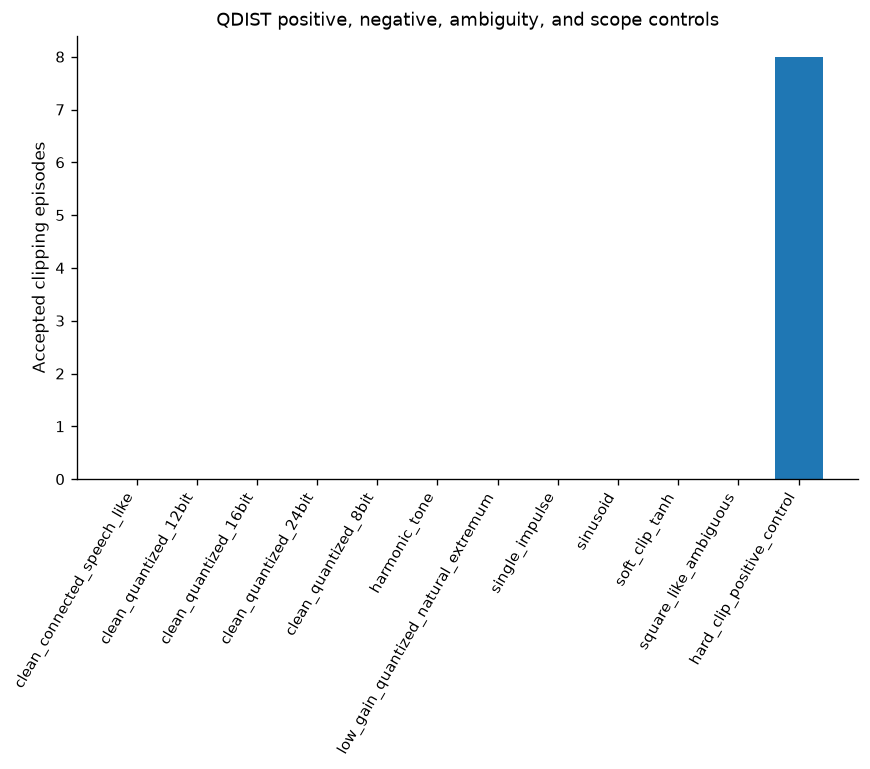

,control,expected_role,status,candidate_count,accepted_plateau_count,event_count,frame_fraction,sample_fraction
0,clean_connected_speech_like,negative_or_scope_control,available_no_events,0,0,0,0.000000,0.0000
1,sinusoid,negative_or_scope_control,available_no_events,0,0,0,0.000000,0.0000
2,harmonic_tone,negative_or_scope_control,available_no_events,0,0,0,0.000000,0.0000
3,square_like_ambiguous,out_of_domain_ambiguous,available_no_events,1730,0,0,0.000000,0.0000
4,single_impulse,negative_or_scope_control,available_no_events,0,0,0,0.000000,0.0000
5,low_gain_quantized_natural_extremum,negative_or_scope_control,available_no_events,0,0,0,0.000000,0.0000
6,soft_clip_tanh,negative_or_scope_control,available_no_events,0,0,0,0.000000,0.0000
7,hard_clip_positive_control,positive,available_events,973,960,8,0.783133,0.2741
8,clean_quantized_8bit,negative_or_scope_control,available_no_events,285,0,0,0.000000,0.0000
9,clean_quantized_12bit,negative_or_scope_control,available_no_events,0,0,0,0.000000,0.0000


,layer,check,passed,observed,required,action_if_failed,blocking
0,G5 discriminant,all clean quantization depths remain event-neg...,True,"[{'control': 'clean_quantized_8bit', 'event_co...",all 0,strengthen quantization guard,True
1,G5 discriminant,"clean speech, tones, impulse, soft clip, and l...",True,"[{'control': 'clean_connected_speech_like', 'e...",all 0,repair false-positive behavior,True
2,G5 ambiguity,square-like two-level waveform is not interpre...,True,[0],0,repair square-like ambiguity guard,True
3,G4 positive,hard-clipping control remains positive,True,[8],>0,repair hard-clipping sensitivity,True


In [5]:
time_axis = np.arange(5 * FS_SYNTH) / FS_SYNTH

sine = (
    0.88
    * np.sin(
        2 * np.pi * 173 * time_axis
    )
)

harmonic = (
    0.58
    * np.sin(
        2 * np.pi * 137 * time_axis
    )
    + 0.22
    * np.sin(
        2 * np.pi * 274 * time_axis + 0.3
    )
    + 0.10
    * np.sin(
        2 * np.pi * 411 * time_axis - 0.2
    )
)

square = (
    0.70
    * np.sign(
        np.sin(
            2 * np.pi * 173 * time_axis
        )
    )
)

impulse = clean.copy()
impulse[
    round(2.0 * FS_SYNTH)
] = 0.99

low_gain_time_axis = (
    np.arange(
        round(2.0 * FS_SYNTH)
    )
    / FS_SYNTH
)

low_gain_quiet_extremum = quantize_pcm(
    0.0175
    * np.sin(
        2
        * np.pi
        * 173.0
        * low_gain_time_axis
    ),
    16,
)

low_gain_quantized_natural_extremum = np.concatenate(
    [
        speech_like_carrier(
            FS_SYNTH,
            duration_sec=2.0,
            seed=311,
        ),
        low_gain_quiet_extremum,
    ]
)


controls = {
    "clean_connected_speech_like": clean,
    "sinusoid": sine,
    "harmonic_tone": harmonic,
    "square_like_ambiguous": square,
    "single_impulse": impulse,
    "low_gain_quantized_natural_extremum": (
        low_gain_quantized_natural_extremum
    ),
    "soft_clip_tanh": apply_soft_clip(
        clean,
        3.0,
    ),
    "hard_clip_positive_control": apply_hard_clip(
        clean,
        0.42,
    ),
}


control_bit_depths = {
    "low_gain_quantized_natural_extremum": 16,
}


for bit_depth in [8, 12, 16, 24]:
    control_name = (
        f"clean_quantized_{bit_depth}bit"
    )

    controls[control_name] = quantize_pcm(
        clean,
        bit_depth,
    )

    control_bit_depths[
        control_name
    ] = bit_depth


control_rows = []
control_ledgers = {}


for name, waveform in controls.items():
    bits = control_bit_depths.get(
        name
    )

    provenance = NativeSignalProvenance(
        codec_name=(
            f"pcm_s{bits}le"
            if bits is not None
            else None
        ),
        sample_format=(
            f"s{bits}"
            if bits is not None
            else None
        ),
        bits_per_raw_sample=bits,
    )

    extraction = extract_qdist(
        waveform,
        FS_SYNTH,
        logical_recording_id=name,
        provenance=provenance,
    )

    control_ledgers[
        name
    ] = extraction.candidate_ledger

    if (
        name
        == "hard_clip_positive_control"
    ):
        expected_role = "positive"

    elif (
        name
        == "square_like_ambiguous"
    ):
        expected_role = (
            "out_of_domain_ambiguous"
        )

    else:
        expected_role = (
            "negative_or_scope_control"
        )

    control_rows.append(
        {
            "control": name,
            "expected_role": expected_role,
            "status": extraction.recording[
                "qdist_status"
            ],
            "candidate_count": (
                extraction.recording.get(
                    "qdist_candidate_plateau_count",
                    0,
                )
            ),
            "accepted_plateau_count": (
                extraction.recording[
                    "qdist_accepted_plateau_count"
                ]
            ),
            "event_count": (
                extraction.recording[
                    "qdist_hard_clip_event_count"
                ]
            ),
            "frame_fraction": (
                extraction.recording[
                    "qdist_hard_clipped_frame_fraction"
                ]
            ),
            "sample_fraction": (
                extraction.recording[
                    "qdist_hard_clipped_sample_fraction"
                ]
            ),
        }
    )


control_table = pd.DataFrame(
    control_rows
)


save_table_bundle(
    control_table,
    TABLES,
    "qdist_v311_discriminant_controls",
)


quantized_control_mask = (
    control_table[
        "control"
    ]
    .str.match(
        r"clean_quantized_\d+bit$"
    )
)


negative_control_names = [
    "clean_connected_speech_like",
    "sinusoid",
    "harmonic_tone",
    "single_impulse",
    "soft_clip_tanh",
    "low_gain_quantized_natural_extremum",
]


discriminant_checks = validation_frame(
    [
        ValidationCheck(
            "G5 discriminant",
            (
                "all clean quantization depths "
                "remain event-negative"
            ),
            (
                control_table.loc[
                    quantized_control_mask,
                    "event_count",
                ]
                .eq(0)
                .all()
            ),
            str(
                control_table.loc[
                    quantized_control_mask,
                    [
                        "control",
                        "event_count",
                    ],
                ].to_dict(
                    "records"
                )
            ),
            "all 0",
            (
                "strengthen quantization "
                "guard"
            ),
        ),
        ValidationCheck(
            "G5 discriminant",
            (
                "clean speech, tones, impulse, "
                "soft clip, and low-gain "
                "quantized natural extrema "
                "remain negative"
            ),
            (
                control_table.loc[
                    control_table[
                        "control"
                    ].isin(
                        negative_control_names
                    ),
                    "event_count",
                ]
                .eq(0)
                .all()
            ),
            str(
                control_table.loc[
                    control_table[
                        "control"
                    ].isin(
                        negative_control_names
                    ),
                    [
                        "control",
                        "event_count",
                    ],
                ].to_dict(
                    "records"
                )
            ),
            "all 0",
            (
                "repair false-positive "
                "behavior"
            ),
        ),
        ValidationCheck(
            "G5 ambiguity",
            (
                "square-like two-level waveform "
                "is not interpreted as "
                "acquisition clipping"
            ),
            (
                control_table.loc[
                    control_table[
                        "control"
                    ].eq(
                        "square_like_ambiguous"
                    ),
                    "event_count",
                ]
                .eq(0)
                .all()
            ),
            str(
                control_table.loc[
                    control_table[
                        "control"
                    ].eq(
                        "square_like_ambiguous"
                    ),
                    "event_count",
                ].tolist()
            ),
            "0",
            (
                "repair square-like "
                "ambiguity guard"
            ),
        ),
        ValidationCheck(
            "G4 positive",
            (
                "hard-clipping control "
                "remains positive"
            ),
            (
                control_table.loc[
                    control_table[
                        "control"
                    ].eq(
                        "hard_clip_positive_control"
                    ),
                    "event_count",
                ]
                .gt(0)
                .all()
            ),
            str(
                control_table.loc[
                    control_table[
                        "control"
                    ].eq(
                        "hard_clip_positive_control"
                    ),
                    "event_count",
                ].tolist()
            ),
            ">0",
            (
                "repair hard-clipping "
                "sensitivity"
            ),
        ),
    ]
)


save_table_bundle(
    discriminant_checks,
    TABLES,
    "qdist_v311_discriminant_checks",
)


fig, ax = plt.subplots(
    figsize=(8.4, 4.8)
)

ordered = (
    control_table
    .sort_values(
        [
            "expected_role",
            "control",
        ]
    )
    .reset_index(
        drop=True
    )
)

x_positions = np.arange(
    len(ordered)
)

ax.bar(
    x_positions,
    ordered[
        "event_count"
    ],
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    ordered[
        "control"
    ],
    rotation=60,
    ha="right",
)

ax.set_ylabel(
    "Accepted clipping episodes"
)

ax.set_title(
    (
        "QDIST positive, negative, ambiguity, "
        "and scope controls"
    )
)

save_publication_figure(
    fig,
    FIGURES,
    "qdist_v311_discriminant_control_events",
    caption=(
        "Accepted QDIST event counts for "
        "prespecified hard-clipping and "
        "competing-mechanism controls."
    ),
    alt_text=(
        "Bar chart with accepted events only "
        "for the hard-clipping positive control; "
        "all negative, ambiguity, and scope "
        "controls have zero accepted events."
    ),
)

plt.show()

display(
    control_table
)

display(
    discriminant_checks
)


## 5. Native-view transformation and codec characterization


In [6]:
transformation_rows = []
reference = hard_clip_bursts(
    speech_like_carrier(FS_SYNTH, duration_sec=5.0, seed=91),
    FS_SYNTH, [(1.0, 2.2)], 0.42,
)
transformations = {
    "native_reference": (reference, FS_SYNTH),
    "polarity_inversion": (-reference, FS_SYNTH),
    "post_clip_attenuation_12db": (reference * 10 ** (-12 / 20), FS_SYNTH),
    "time_shift_137_samples": (np.roll(reference, 137), FS_SYNTH),
    "resample_16k_to_48k_to_16k": (
        signal.resample_poly(signal.resample_poly(reference, 3, 1), 1, 3)[:len(reference)],
        FS_SYNTH,
    ),
    "lowpass_6khz": (
        signal.sosfiltfilt(signal.butter(6, 6000, fs=FS_SYNTH, output="sos"), reference),
        FS_SYNTH,
    ),
}
for name, (waveform, fs) in transformations.items():
    extraction = extract_qdist(waveform, fs, logical_recording_id=name)
    transformation_rows.append({
        "transformation": name,
        **{feature: extraction.recording[feature] for feature in ANALYSIS_FEATURES},
        "event_count": extraction.recording["qdist_hard_clip_event_count"],
        "status": extraction.recording["qdist_status"],
    })

codec_rows = []
if RUN_CODEC_CHARACTERIZATION:
    ffmpeg = shutil.which("ffmpeg")
    if ffmpeg:
        with TemporaryDirectory() as temp_dir:
            temp_dir = Path(temp_dir)
            source_wav = temp_dir / "reference.wav"
            sf.write(source_wav, reference, FS_SYNTH, subtype="PCM_16")
            codec_specs = {
                "opus_32k": ["-c:a", "libopus", "-b:a", "32k"],
                "aac_64k": ["-c:a", "aac", "-b:a", "64k"],
                "mp3_64k": ["-c:a", "libmp3lame", "-b:a", "64k"],
            }
            for codec_name, arguments in codec_specs.items():
                extension = ".ogg" if "opus" in codec_name else ".m4a" if "aac" in codec_name else ".mp3"
                encoded = temp_dir / f"encoded{extension}"
                decoded = temp_dir / f"decoded_{codec_name}.wav"
                first = subprocess.run(
                    [ffmpeg, "-y", "-v", "error", "-i", str(source_wav), *arguments, str(encoded)],
                    capture_output=True, text=True,
                )
                second = subprocess.run(
                    [ffmpeg, "-y", "-v", "error", "-i", str(encoded), "-c:a", "pcm_f32le", str(decoded)],
                    capture_output=True, text=True,
                ) if first.returncode == 0 else None
                if first.returncode == 0 and second and second.returncode == 0:
                    waveform, fs = sf.read(decoded, always_2d=True)
                    extraction = extract_qdist(
                        waveform, int(fs), logical_recording_id=codec_name,
                        provenance=NativeSignalProvenance(codec_name=codec_name),
                    )
                    codec_rows.append({
                        "codec": codec_name,
                        "roundtrip_ok": True,
                        **{feature: extraction.recording[feature] for feature in ANALYSIS_FEATURES},
                        "event_count": extraction.recording["qdist_hard_clip_event_count"],
                    })
                else:
                    codec_rows.append({
                        "codec": codec_name, "roundtrip_ok": False,
                        "error": (first.stderr if first.returncode else second.stderr),
                    })
    else:
        codec_rows.append({"codec": "ffmpeg_unavailable", "roundtrip_ok": False})
transformation_table = pd.DataFrame(transformation_rows)
codec_table = pd.DataFrame(codec_rows)
save_table_bundle(transformation_table, TABLES, "qdist_v311_transformation_characterization")
save_table_bundle(codec_table, TABLES, "qdist_v311_codec_characterization")

reference_row = transformation_table.set_index("transformation").loc["native_reference"]
transform_checks = validation_frame([
    ValidationCheck(
        "G3 transformation", "polarity inversion matches native reference",
        all(np.isclose(
            transformation_table.set_index("transformation").loc["polarity_inversion", feature],
            reference_row[feature], rtol=1e-12, atol=1e-15,
        ) for feature in ANALYSIS_FEATURES),
        "matched", "matched", "repair polarity logic",
    ),
    ValidationCheck(
        "G3 transformation", "post-clipping attenuation matches native reference",
        all(np.isclose(
            transformation_table.set_index("transformation").loc["post_clip_attenuation_12db", feature],
            reference_row[feature], rtol=1e-10, atol=1e-15,
        ) for feature in ANALYSIS_FEATURES),
        "matched", "matched", "remove full-scale dependence",
    ),
    ValidationCheck(
        "G3 transformation", "resampling/filtering are characterized rather than assumed invariant",
        {"resample_16k_to_48k_to_16k", "lowpass_6khz"}.issubset(set(transformation_table["transformation"])),
        "present", "present", "complete transformed-view controls",
    ),
])
save_table_bundle(transform_checks, TABLES, "qdist_v311_transformation_checks")
display(transformation_table)
display(codec_table)
display(transform_checks)


,transformation,qdist_hard_clipped_frame_fraction,qdist_hard_clip_event_rate_per_min,qdist_hard_clipped_sample_fraction,event_count,status
0,native_reference,0.186747,36.0,0.062038,3,available_events
1,polarity_inversion,0.186747,36.0,0.062038,3,available_events
2,post_clip_attenuation_12db,0.186747,36.0,0.062038,3,available_events
3,time_shift_137_samples,0.186747,36.0,0.062038,3,available_events
4,resample_16k_to_48k_to_16k,0.000000,0.0,0.000000,0,available_no_events
5,lowpass_6khz,0.000000,0.0,0.000000,0,available_no_events


,codec,roundtrip_ok,qdist_hard_clipped_frame_fraction,qdist_hard_clip_event_rate_per_min,qdist_hard_clipped_sample_fraction,event_count
0,opus_32k,True,0.0,0.0,0.0,0
1,aac_64k,True,0.0,0.0,0.0,0
2,mp3_64k,True,0.0,0.0,0.0,0


,layer,check,passed,observed,required,action_if_failed,blocking
0,G3 transformation,polarity inversion matches native reference,True,matched,matched,repair polarity logic,True
1,G3 transformation,post-clipping attenuation matches native refer...,True,matched,matched,remove full-scale dependence,True
2,G3 transformation,resampling/filtering are characterized rather ...,True,present,present,complete transformed-view controls,True


## 6. Parameter-neighborhood and episode-grouping sensitivity


In [7]:
sensitivity_signal = hard_clip_bursts(
    speech_like_carrier(FS_SYNTH, duration_sec=6.0, seed=105),
    FS_SYNTH, [(1.0, 1.5), (3.0, 3.6)], 0.43,
)
variants = {
    "default": PARAMETERS,
    "plateau_min_3": replace(PARAMETERS, minimum_plateau_samples=3),
    "plateau_min_5": replace(PARAMETERS, minimum_plateau_samples=5),
    "singleton_min_6": replace(PARAMETERS, minimum_singleton_plateau_samples=6),
    "singleton_min_8": replace(PARAMETERS, minimum_singleton_plateau_samples=8),
    "edge_support_6": replace(PARAMETERS, minimum_edge_zone_samples=6, minimum_level_cluster_samples=6),
    "edge_support_10": replace(PARAMETERS, minimum_edge_zone_samples=10, minimum_level_cluster_samples=10),
    "merge_10ms": replace(PARAMETERS, episode_merge_gap_ms=10.0),
    "merge_30ms": replace(PARAMETERS, episode_merge_gap_ms=30.0),
}
sensitivity_rows = []
for name, parameters in variants.items():
    extraction = extract_qdist(
        sensitivity_signal, FS_SYNTH,
        logical_recording_id=name, parameters=parameters,
    )
    sensitivity_rows.append({
        "variant": name,
        "accepted_plateau_count": extraction.recording["qdist_accepted_plateau_count"],
        "event_count": extraction.recording["qdist_hard_clip_event_count"],
        **{feature: extraction.recording[feature] for feature in ANALYSIS_FEATURES},
    })
sensitivity_table = pd.DataFrame(sensitivity_rows)
save_table_bundle(sensitivity_table, TABLES, "qdist_v311_parameter_sensitivity_synthetic")
default_row = sensitivity_table.set_index("variant").loc["default"]
burden_variants = sensitivity_table.loc[~sensitivity_table["variant"].str.startswith("merge_")]
relative_sample_change = (
    (burden_variants["qdist_hard_clipped_sample_fraction"] - default_row["qdist_hard_clipped_sample_fraction"]).abs()
    / max(default_row["qdist_hard_clipped_sample_fraction"], 1e-12)
)
parameter_checks = validation_frame([
    ValidationCheck(
        "G6 robustness", "reasonable morphology/edge variants preserve positive detection",
        burden_variants["event_count"].gt(0).all(),
        str(burden_variants[["variant","event_count"]].to_dict("records")),
        "all >0", "repair threshold cliff",
    ),
    ValidationCheck(
        "G6 robustness", "sample burden remains within 25% across non-merge variants",
        relative_sample_change.max() <= 0.25,
        f"max relative change={relative_sample_change.max():.3f}", "<=0.25",
        "recalibrate unstable threshold",
    ),
    ValidationCheck(
        "G8 redundancy", "merge variants leave sample and frame burden unchanged",
        all(np.isclose(
            sensitivity_table.set_index("variant").loc[name, "qdist_hard_clipped_sample_fraction"],
            default_row["qdist_hard_clipped_sample_fraction"], atol=1e-15,
        ) for name in ["merge_10ms", "merge_30ms"]),
        "unchanged", "unchanged", "repair ledger separation",
    ),
])
save_table_bundle(parameter_checks, TABLES, "qdist_v311_parameter_checks")
display(sensitivity_table)
display(parameter_checks)


,variant,accepted_plateau_count,event_count,qdist_hard_clipped_frame_fraction,qdist_hard_clip_event_rate_per_min,qdist_hard_clipped_sample_fraction
0,default,200,4,0.135,40.0,0.044427
1,plateau_min_3,200,4,0.135,40.0,0.044427
2,plateau_min_5,196,4,0.130,40.0,0.044260
3,singleton_min_6,200,4,0.135,40.0,0.044427
4,singleton_min_8,200,4,0.135,40.0,0.044427
5,edge_support_6,200,4,0.135,40.0,0.044427
6,edge_support_10,200,4,0.135,40.0,0.044427
7,merge_10ms,200,4,0.135,40.0,0.044427
8,merge_30ms,200,4,0.135,40.0,0.044427


,layer,check,passed,observed,required,action_if_failed,blocking
0,G6 robustness,reasonable morphology/edge variants preserve p...,True,"[{'variant': 'default', 'event_count': 4}, {'v...",all >0,repair threshold cliff,True
1,G6 robustness,sample burden remains within 25% across non-me...,True,max relative change=0.004,<=0.25,recalibrate unstable threshold,True
2,G8 redundancy,merge variants leave sample and frame burden u...,True,unchanged,unchanged,repair ledger separation,True


## 7. Frozen cohort and native-source provenance contract


In [8]:
def read_table(path):
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)


def table_file(stem):
    stem = Path(stem)
    for suffix in [".parquet", ".csv"]:
        candidate = stem.with_suffix(suffix)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Missing table bundle for {stem}")


def as_bool(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.astype(str).str.strip().str.lower().isin({"1", "true", "yes", "y"})


def discover_interval_table(folder):
    candidates = []
    for path in Path(folder).rglob("*"):
        if path.suffix.lower() not in {".csv", ".parquet"} or not path.is_file():
            continue
        try:
            frame = read_table(path)
        except Exception:
            continue
        columns = set(frame.columns)
        if not ({"start_sec", "end_sec"}.issubset(columns) or {"start", "end"}.issubset(columns)):
            continue
        if not {"view", "segment_type", "label", "region"}.intersection(columns):
            continue
        if not {"logical_recording_id", "file_name"}.intersection(columns):
            continue
        score = (
            8 * ("frozen" in path.stem.lower())
            + 6 * ("interval" in path.stem.lower())
            + 2 * (path.suffix.lower() == ".parquet")
        )
        candidates.append((score, path, frame))
    if not candidates:
        raise FileNotFoundError(f"No frozen interval table under {folder}")
    candidates.sort(key=lambda item: (-item[0], str(item[1])))
    if len(candidates) > 1 and candidates[0][0] == candidates[1][0]:
        raise RuntimeError("Tied interval-table candidates; resolve upstream.")
    return candidates[0][1], candidates[0][2]


def load_frozen_inputs():
    cfg = yaml.safe_load(CONFIG.read_text(encoding="utf-8"))
    segmentation_version = str(cfg.get("segmentation_freeze", {}).get(
        "version", cfg.get("data_freeze", {}).get("version", "v1")
    ))
    data_version = str(cfg.get("data_freeze", {}).get("version", "v1"))
    segmentation_folder = MAIN_OUTPUTS / "01_SEGMENTATION_FREEZE" / segmentation_version
    data_folder = MAIN_OUTPUTS / "00_DATA_FREEZE" / data_version
    decisions_path = table_file(segmentation_folder / "frozen_segmentation_decisions")
    recordings_path = table_file(data_folder / "frozen_bamboo_recordings")
    intervals_path, intervals = discover_interval_table(segmentation_folder)
    decisions, recordings = read_table(decisions_path), read_table(recordings_path)
    if "segmentation_analysis_eligible" not in decisions:
        raise ValueError("Frozen decisions lack segmentation_analysis_eligible")
    eligible = decisions.loc[as_bool(decisions["segmentation_analysis_eligible"])].copy()
    if "logical_recording_id" not in intervals:
        mapping = decisions[["file_name", "logical_recording_id"]].drop_duplicates()
        if mapping["file_name"].duplicated().any():
            raise ValueError("file_name is not unique in frozen decisions")
        intervals = intervals.merge(mapping, on="file_name", how="left", validate="many_to_one")
    for frame in [eligible, recordings, intervals]:
        frame["logical_recording_id"] = frame["logical_recording_id"].astype(str)
    media_column = next((column for column in [
        "media_path", "selected_media_path", "file_path", "selected_path"
    ] if column in recordings), None)
    if media_column is None:
        raise ValueError("Frozen recording table lacks selected media path")
    recordings = recordings.rename(columns={media_column: "media_path"})
    analysis_recordings = eligible[["logical_recording_id"]].merge(
        recordings.drop_duplicates("logical_recording_id"),
        on="logical_recording_id", how="left", validate="one_to_one",
    )
    intervals = intervals.rename(columns={"start": "start_sec", "end": "end_sec"})
    view_column = next((column for column in [
        "view", "segment_type", "label", "region"
    ] if column in intervals), None)
    intervals = intervals.rename(columns={view_column: "view"})
    if "profile" in intervals and intervals["profile"].astype(str).eq("primary").any():
        intervals = intervals.loc[intervals["profile"].astype(str).eq("primary")].copy()
    available = sorted(intervals["view"].dropna().astype(str).unique())
    strict = next((name for name in [
        "strict_speech", "primary_speech", "final_speech", "speech"
    ] if name in available), None)
    checks = validation_frame([
        ValidationCheck(
            "G1 input", "one eligible row per recording",
            not analysis_recordings["logical_recording_id"].duplicated().any(),
            str(len(analysis_recordings)), "unique IDs", "repair data freeze",
        ),
        ValidationCheck(
            "G1 input", "media path complete",
            analysis_recordings["media_path"].notna().all(),
            str(int(analysis_recordings["media_path"].isna().sum())), "0 missing",
            "repair data freeze",
        ),
        ValidationCheck(
            "G1 input", "strict-speech intervals available only to define continuous task span",
            strict is not None, str(strict), "available", "repair segmentation export",
        ),
    ])
    provenance = pd.DataFrame([
        {"artifact": "frozen decisions", "path": str(decisions_path), "sha256": sha256_file(decisions_path)},
        {"artifact": "frozen recordings", "path": str(recordings_path), "sha256": sha256_file(recordings_path)},
        {"artifact": "frozen intervals", "path": str(intervals_path), "sha256": sha256_file(intervals_path)},
        {"artifact": "qdist implementation", "path": str(ROOT / "src/paper1_qc/qdist.py"), "sha256": sha256_file(ROOT / "src/paper1_qc/qdist.py")},
    ])
    return {
        "recordings": analysis_recordings,
        "intervals": intervals,
        "strict_speech_view": strict,
        "checks": checks,
        "provenance": provenance,
    }


if RUN_COHORT_EXTRACTION:
    frozen = load_frozen_inputs()
    input_checks = frozen["checks"]
    if not gate_passed(input_checks):
        display(input_checks)
        raise RuntimeError("Frozen input contract failed.")
    save_table_bundle(input_checks, TABLES, "qdist_v311_input_contract")
    save_table_bundle(frozen["provenance"], TABLES, "qdist_v311_input_provenance")
else:
    frozen = None
    input_checks = validation_frame([
        ValidationCheck("G1 input", "frozen cohort loaded", False, "NOT RUN", "completed", "enable cohort extraction")
    ])
display(input_checks)


,layer,check,passed,observed,required,action_if_failed,blocking
0,G1 input,one eligible row per recording,True,519,unique IDs,repair data freeze,True
1,G1 input,media path complete,True,0,0 missing,repair data freeze,True
2,G1 input,strict-speech intervals available only to defi...,True,strict_speech,available,repair segmentation export,True


## 8. Memory-safe native-waveform cohort extraction and event ledgers


In [9]:
def intervals_for(recording_id):
    local = frozen["intervals"].loc[
        frozen["intervals"]["logical_recording_id"].eq(str(recording_id))
        & frozen["intervals"]["view"].astype(str).eq(str(frozen["strict_speech_view"]))
    ].sort_values(["start_sec", "end_sec"])
    return [
        TimeInterval(float(row.start_sec), float(row.end_sec))
        for row in local.itertuples(index=False)
        if np.isfinite(row.start_sec) and np.isfinite(row.end_sec) and row.end_sec > row.start_sec
    ]


def task_span_for(recording_id):
    intervals = intervals_for(recording_id)
    if not intervals:
        return TimeInterval(0.0, 0.0)
    return TimeInterval(
        min(item.start_sec for item in intervals),
        max(item.end_sec for item in intervals),
    )


def media_path_for(row):
    path = Path(str(row.media_path))
    return path if path.is_absolute() else ROOT / path


def safe_id(recording_id):
    return "".join(
        character if character.isalnum() or character in "-_" else "_"
        for character in str(recording_id)
    )


def checkpoint_path(recording_id):
    return CHECKPOINTS / f"{safe_id(recording_id)}.qdist.pkl.gz"


def write_checkpoint_atomic(path, payload):
    temporary = path.with_name(f".{path.name}.tmp")
    with gzip.open(temporary, "wb", compresslevel=CHECKPOINT_COMPRESSION_LEVEL) as handle:
        pickle.dump(payload, handle, protocol=5)
    temporary.replace(path)


def read_checkpoint(path):
    with gzip.open(path, "rb") as handle:
        return pickle.load(handle)


def concat_nonempty(frames):
    clean = [frame for frame in frames if isinstance(frame, pd.DataFrame) and len(frame)]
    return pd.concat(clean, ignore_index=True) if clean else pd.DataFrame()


recording_table = pd.DataFrame()
candidate_ledger = pd.DataFrame()
accepted_plateau_ledger = pd.DataFrame()
episode_ledger = pd.DataFrame()
edge_ledger = pd.DataFrame()
extraction_errors = pd.DataFrame(columns=["logical_recording_id", "error_type", "message"])
extraction_runtime = pd.DataFrame()

if RUN_COHORT_EXTRACTION:
    ffmpeg, ffprobe = shutil.which("ffmpeg"), shutil.which("ffprobe")
    if not ffmpeg or not ffprobe:
        raise RuntimeError("ffmpeg and ffprobe are required for QDIST extraction")
    ffmpeg_version = subprocess.run(
        [ffmpeg, "-version"], capture_output=True, text=True
    ).stdout.splitlines()[0]
    signature_payload = {
        "measurement_version": MEASUREMENT_VERSION,
        "implementation_sha256": sha256_file(ROOT / "src/paper1_qc/qdist.py"),
        "media_implementation_sha256": sha256_file(ROOT / "src/paper1_qc/media.py"),
        "parameters": PARAMETERS.to_dict(),
        "input_sha256": frozen["provenance"][["artifact", "sha256"]].to_dict("records"),
    }
    checkpoint_signature = hashlib.sha256(
        json.dumps(signature_payload, sort_keys=True).encode("utf-8")
    ).hexdigest()

    recording_rows, candidate_frames, accepted_frames = [], [], []
    episode_frames, edge_frames, errors, runtime_rows = [], [], [], []
    started = perf_counter()
    total_recordings = len(frozen["recordings"])

    for ordinal, row in enumerate(frozen["recordings"].itertuples(index=False), start=1):
        recording_id = str(row.logical_recording_id)
        path = checkpoint_path(recording_id)
        bundle = None
        reused = False
        item_started = perf_counter()
        try:
            if RESUME_FROM_CHECKPOINTS and path.exists():
                prior = read_checkpoint(path)
                if prior.get("checkpoint_signature") == checkpoint_signature:
                    bundle = prior
                    reused = True

            if bundle is None:
                media_path = media_path_for(row)
                decoded = decode_native_audio(media_path, ffmpeg=ffmpeg, ffprobe=ffprobe)
                source_hash = getattr(row, "sha256", None)
                if source_hash is None or pd.isna(source_hash):
                    source_hash = sha256_file(media_path)
                bits = decoded.probe.get("bits_per_raw_sample")
                bits = int(bits) if pd.notna(bits) else None
                provenance = NativeSignalProvenance(
                    native_view_verified=True,
                    known_preprocessing_applied=False,
                    codec_name=decoded.probe.get("codec_name"),
                    sample_format=decoded.probe.get("sample_format"),
                    bits_per_raw_sample=bits,
                    container_format=decoded.probe.get("container_format"),
                    channel_layout=decoded.probe.get("channel_layout"),
                    source_path=str(media_path),
                    source_sha256=str(source_hash),
                    decoder="ffmpeg",
                    decoder_version=ffmpeg_version,
                    decode_arguments=(
                        "first audio stream -> native-rate pcm_f32le; "
                        "no mono reduction/resampling/normalization/filtering"
                    ),
                )
                extraction = extract_qdist(
                    decoded.native,
                    decoded.sample_rate_native,
                    task_span=task_span_for(recording_id),
                    logical_recording_id=recording_id,
                    provenance=provenance,
                    parameters=PARAMETERS,
                )
                recording_row = {
                    **extraction.recording,
                    "qdist_checkpoint_signature": checkpoint_signature,
                    "file_name": getattr(row, "file_name", media_path.name),
                    "media_path": str(media_path),
                }
                bundle = {
                    "checkpoint_signature": checkpoint_signature,
                    "recording": recording_row,
                    "candidates": extraction.candidate_ledger,
                    "accepted": extraction.accepted_plateau_ledger,
                    "episodes": extraction.episode_ledger,
                    "edges": extraction.edge_ledger,
                }
                write_checkpoint_atomic(path, bundle)

            recording_rows.append(bundle["recording"])
            candidate_frames.append(bundle["candidates"])
            accepted_frames.append(bundle["accepted"])
            episode_frames.append(bundle["episodes"])
            edge_frames.append(bundle["edges"])
        except Exception as exc:
            errors.append({
                "logical_recording_id": recording_id,
                "error_type": type(exc).__name__,
                "message": str(exc),
            })
        runtime_rows.append({
            "logical_recording_id": recording_id,
            "checkpoint_reused": reused,
            "elapsed_sec": perf_counter() - item_started,
            "checkpoint_path": str(path),
        })
        if ordinal % PROGRESS_EVERY == 0 or ordinal == total_recordings:
            elapsed = perf_counter() - started
            rate = ordinal / max(elapsed, 1e-12)
            remaining = (total_recordings - ordinal) / max(rate, 1e-12)
            print(
                f"QDIST {ordinal}/{total_recordings} | {rate:.2f} recordings/s | "
                f"ETA {remaining/60:.1f} min"
            )
        if ordinal % 50 == 0:
            gc.collect()

    recording_table = pd.DataFrame(recording_rows)
    candidate_ledger = concat_nonempty(candidate_frames)
    accepted_plateau_ledger = concat_nonempty(accepted_frames)
    episode_ledger = concat_nonempty(episode_frames)
    edge_ledger = concat_nonempty(edge_frames)
    extraction_errors = pd.DataFrame(errors, columns=extraction_errors.columns)
    extraction_runtime = pd.DataFrame(runtime_rows)

    analysis_columns = [
        "logical_recording_id", *ANALYSIS_FEATURES,
        *[f"{feature}_status" for feature in ANALYSIS_FEATURES],
        "qdist_status", "qdist_available", "qdist_support_tier",
        "qdist_hard_clip_event_count", "qdist_accepted_plateau_count",
        "qdist_finite_exposure_sec", "qdist_task_span_duration_sec",
        "qdist_native_sample_rate_hz", "qdist_native_channel_count",
        "qdist_codec_name", "qdist_parameter_hash",
        "qdist_flat_run_count_all_amplitudes",
        "qdist_flat_run_count_at_recording_edge",
        "qdist_flat_run_prefilter_reduction_fraction",
    ]
    analysis_feature_table = recording_table[
        [column for column in analysis_columns if column in recording_table]
    ].copy()
    save_table_bundle(recording_table, TABLES, "qdist_v311_recording_features")
    save_table_bundle(analysis_feature_table, TABLES, "qdist_v311_analysis_features")
    save_table_bundle(candidate_ledger, TABLES, "qdist_v311_candidate_plateau_ledger")
    save_table_bundle(accepted_plateau_ledger, TABLES, "qdist_v311_accepted_plateau_ledger")
    save_table_bundle(episode_ledger, TABLES, "qdist_v311_episode_ledger")
    save_table_bundle(edge_ledger, TABLES, "qdist_v311_edge_ledger")
    save_table_bundle(extraction_errors, AUDIT, "qdist_v311_extraction_errors")
    save_table_bundle(extraction_runtime, AUDIT, "qdist_v311_extraction_runtime")
else:
    analysis_feature_table = pd.DataFrame()

extraction_checks = validation_frame([
    ValidationCheck(
        "G7 extraction", "no extraction exceptions",
        RUN_COHORT_EXTRACTION and extraction_errors.empty,
        str(len(extraction_errors)), "0", "resolve every extraction error",
    ),
    ValidationCheck(
        "G7 extraction", "one recording output per frozen eligible recording",
        RUN_COHORT_EXTRACTION and len(recording_table) == len(frozen["recordings"]),
        str(len(recording_table)),
        str(len(frozen["recordings"]) if RUN_COHORT_EXTRACTION else "not run"),
        "repair checkpoints or source resolution",
    ),
    ValidationCheck(
        "G7 extraction", "available zeros remain zero and unavailable values remain missing",
        RUN_COHORT_EXTRACTION and (
            recording_table.loc[
                recording_table["qdist_status"].eq("available_no_events"),
                list(ANALYSIS_FEATURES),
            ].fillna(-1).eq(0).all().all()
            and recording_table.loc[
                ~recording_table["qdist_available"].astype(bool),
                list(ANALYSIS_FEATURES),
            ].isna().all().all()
        ),
        "audited", "contract satisfied", "repair missingness/status logic",
    ),
    ValidationCheck(
        "G7 performance", "recording-edge prefilter removes low-level flat-run explosion",
        RUN_COHORT_EXTRACTION and (
            recording_table["qdist_flat_run_prefilter_reduction_fraction"].median() >= 0.95
        ),
        (
            f"median reduction={recording_table['qdist_flat_run_prefilter_reduction_fraction'].median():.4f}"
            if len(recording_table) else "not run"
        ),
        ">=0.95", "inspect magnitude prefilter and candidate generation",
        blocking=False,
    ),
])
save_table_bundle(extraction_checks, TABLES, "qdist_v311_extraction_checks")
display(recording_table.head())
display(extraction_errors)
display(extraction_checks)


QDIST 25/519 | 1548.94 recordings/s | ETA 0.0 min
QDIST 50/519 | 1736.31 recordings/s | ETA 0.0 min
QDIST 75/519 | 563.46 recordings/s | ETA 0.0 min
QDIST 100/519 | 617.80 recordings/s | ETA 0.0 min
QDIST 125/519 | 482.50 recordings/s | ETA 0.0 min
QDIST 150/519 | 554.16 recordings/s | ETA 0.0 min
QDIST 175/519 | 440.68 recordings/s | ETA 0.0 min
QDIST 200/519 | 488.46 recordings/s | ETA 0.0 min
QDIST 225/519 | 438.81 recordings/s | ETA 0.0 min
QDIST 250/519 | 475.45 recordings/s | ETA 0.0 min
QDIST 275/519 | 436.70 recordings/s | ETA 0.0 min
QDIST 300/519 | 467.76 recordings/s | ETA 0.0 min
QDIST 325/519 | 444.59 recordings/s | ETA 0.0 min
QDIST 350/519 | 459.86 recordings/s | ETA 0.0 min
QDIST 375/519 | 438.61 recordings/s | ETA 0.0 min
QDIST 400/519 | 461.73 recordings/s | ETA 0.0 min
QDIST 425/519 | 447.16 recordings/s | ETA 0.0 min
QDIST 450/519 | 455.55 recordings/s | ETA 0.0 min
QDIST 475/519 | 419.36 recordings/s | ETA 0.0 min
QDIST 500/519 | 437.13 recordings/s | ETA 0.0 min
Q

,logical_recording_id,qdist_measurement_version,qdist_parameter_hash,qdist_signal_view,qdist_task_span_start_sec,qdist_task_span_end_sec,qdist_task_span_start_sample_native,qdist_task_span_end_sample_native_exclusive,qdist_task_span_duration_sec,qdist_native_sample_rate_hz,qdist_native_channel_count,qdist_finite_fraction,qdist_finite_channel_sample_count,qdist_finite_time_sample_count,qdist_frame_length_ms,qdist_frame_length_samples,qdist_complete_frame_count,qdist_episode_merge_gap_ms,qdist_support_tier,qdist_status,qdist_available,qdist_accepted_plateau_count,qdist_hard_clip_event_count,qdist_affected_channel_count,qdist_any_channel_affected_time_fraction,qdist_near_fullscale_channel_sample_fraction,qdist_hard_clip_event_rate_ci95_low_per_min,qdist_hard_clip_event_rate_ci95_high_per_min,qdist_native_view_verified,qdist_known_preprocessing_applied,qdist_codec_name,qdist_sample_format,qdist_bits_per_raw_sample,qdist_container_format,qdist_channel_layout,qdist_source_path,qdist_source_sha256,qdist_decoded_sha256,qdist_decoder,qdist_decoder_version,qdist_decode_arguments,qdist_hard_clipped_frame_fraction,qdist_hard_clipped_frame_fraction_status,qdist_hard_clip_event_rate_per_min,qdist_hard_clip_event_rate_per_min_status,qdist_hard_clipped_sample_fraction,qdist_hard_clipped_sample_fraction_status,qdist_candidate_plateau_count,qdist_rejected_candidate_count,qdist_flat_run_count_all_amplitudes,qdist_flat_run_count_at_recording_edge,qdist_flat_run_prefilter_reduction_fraction,qdist_finite_exposure_sec,qdist_inferred_integer_bits,qdist_quantization_step,qdist_checkpoint_signature,file_name,media_path
0,C02_1075_1_20260420_240_PSG_BAMBOO,qdist-v3.1.1,7802da72a6654f744fd4f5d7d53f7f1efe62356c043ecc...,native_rate_multichannel_first_decoded_audio_s...,3.122,39.182,137680,1727927,36.060023,44100,1,1.0,1590247,1590247,30.0,1323,1202,20.0,high,available_no_events,True,0,0,0,0.0,0.000000,0.0,6.137899,True,False,pcm_s16le,s16,None,wav,None,C:\Users\musikicn\Desktop\Nevena_project\Data_...,b89d44cac3946c2f35580a8607ed4224caa31227ce56b1...,2c5b05d41a46aa36b124ca77dc7dac849f15d70f02aebf...,ffmpeg,ffmpeg version 8.0.1-essentials_build-www.gyan...,first audio stream -> native-rate pcm_f32le; n...,0.0,available_no_events,0.0,available_no_events,0.0,available_no_events,9,9,76511,2055,0.973141,36.060023,16,0.000031,ae1ce6d3cefc34be52fdd75efcae6d1057964548eebd23...,C02_1075_1_20260420_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_...
1,C02_1075_2_20260421_240_PSG_BAMBOO,qdist-v3.1.1,7802da72a6654f744fd4f5d7d53f7f1efe62356c043ecc...,native_rate_multichannel_first_decoded_audio_s...,3.890,37.646,171549,1660189,33.756009,44100,1,1.0,1488640,1488640,30.0,1323,1125,20.0,high,available_no_events,True,0,0,0,0.0,0.000000,0.0,6.556840,True,False,pcm_s16le,s16,None,wav,None,C:\Users\musikicn\Desktop\Nevena_project\Data_...,47d0ed8a276b6f032d80fe2e5a1263772fec18ccd6b5e4...,03090acb8930f6cb682b62bf1b53f3a96e1890263e9332...,ffmpeg,ffmpeg version 8.0.1-essentials_build-www.gyan...,first audio stream -> native-rate pcm_f32le; n...,0.0,available_no_events,0.0,available_no_events,0.0,available_no_events,1,1,63701,636,0.990016,33.756009,16,0.000031,ae1ce6d3cefc34be52fdd75efcae6d1057964548eebd23...,C02_1075_2_20260421_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_...
2,C03_1075_1_20260412_240_PSG_BAMBOO,qdist-v3.1.1,7802da72a6654f744fd4f5d7d53f7f1efe62356c043ecc...,native_rate_multichannel_first_decoded_audio_s...,2.450,42.062,108045,1854935,39.612018,44100,1,1.0,1746890,1746890,30.0,1323,1320,20.0,high,available_no_events,True,0,0,0,0.0,0.000022,0.0,5.587516,True,False,pcm_s16le,s16,None,wav,None,C:\Users\musikicn\Desktop\Nevena_project\Data_...,ea97be020d3e65bfa68a6b06d2f0d6b57639997ad2f7a6...,d42f9e77b42d31a793c552f5eaa389f5476e279a372343...,ffmpeg,ffmpeg version 8.0.1-essentials_build-www.gyan...,first audio stream -> native-rate pcm_f32le; n...,0.0,available_no_events,0.0,available_no_events,0.0,available_no_events,0,0,53683,12

,logical_recording_id,error_type,message


,layer,check,passed,observed,required,action_if_failed,blocking
0,G7 extraction,no extraction exceptions,True,0,0,resolve every extraction error,True
1,G7 extraction,one recording output per frozen eligible recor...,True,519,519,repair checkpoints or source resolution,True
2,G7 extraction,available zeros remain zero and unavailable va...,True,audited,contract satisfied,repair missingness/status logic,True
3,G7 performance,recording-edge prefilter removes low-level fla...,True,median reduction=0.9898,>=0.95,inspect magnitude prefilter and candidate gene...,False


## 9. Independent cohort reconstruction audit


In [10]:
reconstruction_rows = []
if RUN_COHORT_EXTRACTION and len(recording_table):
    for row in recording_table.itertuples(index=False):
        recording_id = str(row.logical_recording_id)
        local_accepted = accepted_plateau_ledger.loc[
            accepted_plateau_ledger["logical_recording_id"].astype(str).eq(recording_id)
        ] if len(accepted_plateau_ledger) else accepted_plateau_ledger
        local_episodes = episode_ledger.loc[
            episode_ledger["logical_recording_id"].astype(str).eq(recording_id)
        ] if len(episode_ledger) else episode_ledger
        reconstructed = reconstruct_qdist_features(
            local_accepted, local_episodes,
            finite_channel_sample_count=int(row.qdist_finite_channel_sample_count),
            finite_time_sample_count=int(row.qdist_finite_time_sample_count),
            finite_exposure_sec=float(getattr(row, "qdist_finite_exposure_sec", np.nan)),
            frame_length_samples=int(row.qdist_frame_length_samples),
            complete_frame_count=int(row.qdist_complete_frame_count),
        )
        for feature in ANALYSIS_FEATURES:
            stored = float(getattr(row, feature)) if pd.notna(getattr(row, feature)) else np.nan
            rebuilt = reconstructed[feature]
            reconstruction_rows.append({
                "logical_recording_id": recording_id,
                "feature": feature,
                "stored": stored,
                "reconstructed": rebuilt,
                "absolute_difference": abs(stored - rebuilt) if np.isfinite(stored) and np.isfinite(rebuilt) else np.nan,
                "both_missing": bool(pd.isna(stored) and pd.isna(rebuilt)),
            })
reconstruction_table = pd.DataFrame(reconstruction_rows)
save_table_bundle(reconstruction_table, TABLES, "qdist_v311_cohort_reconstruction")
finite_differences = reconstruction_table["absolute_difference"].dropna() if len(reconstruction_table) else pd.Series(dtype=float)
reconstruction_checks = validation_frame([
    ValidationCheck(
        "G2 reconstruction", "every available cohort value reconstructs from saved ledgers",
        RUN_COHORT_EXTRACTION and len(reconstruction_table) and (finite_differences.max() if len(finite_differences) else 0) <= 1e-15,
        f"max difference={(finite_differences.max() if len(finite_differences) else np.nan):.3g}", "<=1e-15",
        "repair checkpoint/ledger aggregation",
    )
])
save_table_bundle(reconstruction_checks, TABLES, "qdist_v311_reconstruction_checks")
display(reconstruction_checks)


,layer,check,passed,observed,required,action_if_failed,blocking
0,G2 reconstruction,every available cohort value reconstructs from...,True,max difference=0,<=1e-15,repair checkpoint/ledger aggregation,True


## 10. Sparse-event cohort availability, exposure, and morphology


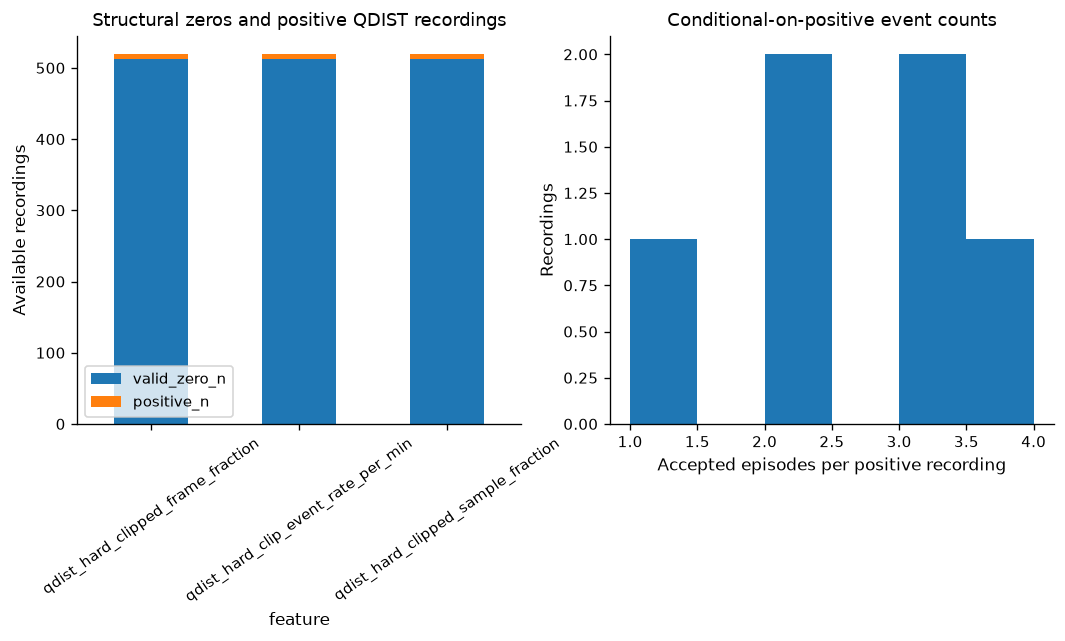

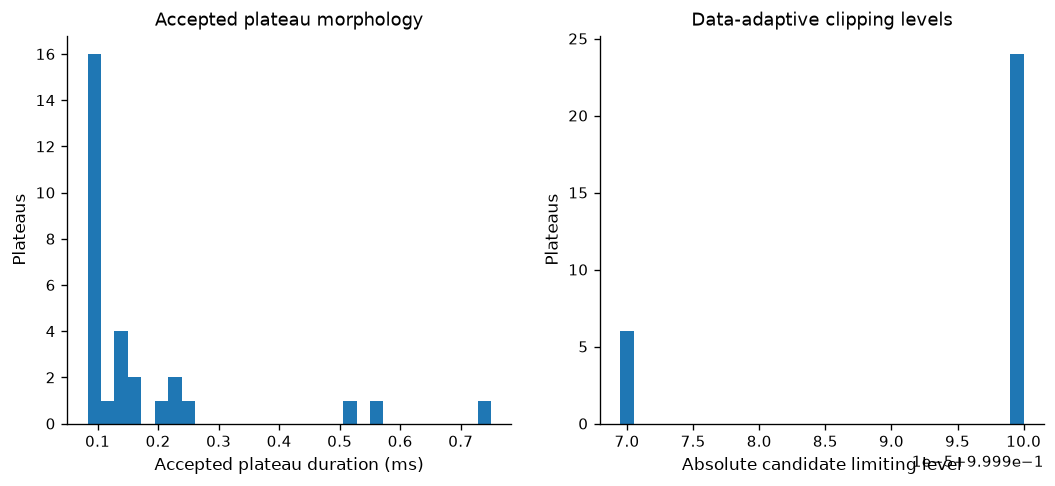

,feature,recordings,available_n,available_fraction,valid_zero_n,valid_zero_fraction_available,positive_n,positive_fraction_available,positive_median,positive_q25,positive_q75,maximum
0,qdist_hard_clipped_frame_fraction,519,519,1.0,513,0.988439,6,0.011561,0.001852,0.001641,0.002862,0.004600
1,qdist_hard_clip_event_rate_per_min,519,519,1.0,513,0.988439,6,0.011561,3.677658,3.281166,3.842449,7.353838
2,qdist_hard_clipped_sample_fraction,519,519,1.0,513,0.988439,6,0.011561,0.000009,0.000006,0.000017,0.000061


,reason,candidate_failures
2,insufficient_relative_edge_magnitude,748
3,insufficient_repeated_edge_support,633
6,weak_or_nondirectional_plateau_edges,618
1,insufficient_edge_zone_support,515
4,meaningful_support_beyond_proposed_edge,481
5,no_edge_occupancy_excess,426
0,edge_not_concentrated_vs_interior,370


,layer,check,passed,observed,required,action_if_failed,blocking
0,G7 empirical,cohort availability and zero mass are explicit...,True,3,3,complete sparse-event summary,True
1,G7 empirical,accepted limiting levels are not concentrated ...,True,1.0,>1e-4 or no events,inspect quantization/near-zero false positives,True


In [11]:
empirical_summary = pd.DataFrame()
rejection_summary = pd.DataFrame()
if RUN_COHORT_EXTRACTION and len(recording_table):
    empirical_rows = []
    for feature in ANALYSIS_FEATURES:
        values = pd.to_numeric(recording_table[feature], errors="coerce")
        nonzero = values.loc[values.gt(0)]
        empirical_rows.append({
            "feature": feature,
            "recordings": len(values),
            "available_n": int(values.notna().sum()),
            "available_fraction": float(values.notna().mean()),
            "valid_zero_n": int(values.eq(0).sum()),
            "valid_zero_fraction_available": float(values.dropna().eq(0).mean()) if values.notna().any() else np.nan,
            "positive_n": int(values.gt(0).sum()),
            "positive_fraction_available": float(values.dropna().gt(0).mean()) if values.notna().any() else np.nan,
            "positive_median": float(nonzero.median()) if len(nonzero) else np.nan,
            "positive_q25": float(nonzero.quantile(0.25)) if len(nonzero) else np.nan,
            "positive_q75": float(nonzero.quantile(0.75)) if len(nonzero) else np.nan,
            "maximum": float(values.max()) if values.notna().any() else np.nan,
        })
    empirical_summary = pd.DataFrame(empirical_rows)
    if len(candidate_ledger):
        rejection_summary = (
            candidate_ledger.loc[~candidate_ledger["accepted"].astype(bool)]
            .assign(reason=lambda frame: frame["rejection_reason"].str.split("\\|"))
            .explode("reason").groupby("reason", dropna=False).size()
            .rename("candidate_failures").reset_index().sort_values("candidate_failures", ascending=False)
        )
    status_summary = recording_table.groupby("qdist_status", dropna=False).size().rename("recordings").reset_index()
    codec_summary = recording_table.groupby(
        ["qdist_codec_name", "qdist_status"], dropna=False
    ).size().rename("recordings").reset_index()
    save_table_bundle(empirical_summary, TABLES, "qdist_v311_empirical_feature_summary")
    save_table_bundle(status_summary, TABLES, "qdist_v311_status_summary")
    save_table_bundle(codec_summary, TABLES, "qdist_v311_codec_status_summary")
    save_table_bundle(rejection_summary, TABLES, "qdist_v311_rejection_reason_summary")

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
    positive_counts = empirical_summary.set_index("feature")[["valid_zero_n", "positive_n"]]
    positive_counts.plot(kind="bar", stacked=True, ax=axes[0])
    axes[0].set_ylabel("Available recordings")
    axes[0].set_title("Structural zeros and positive QDIST recordings")
    axes[0].tick_params(axis="x", rotation=35)
    positive_rows = recording_table.loc[recording_table["qdist_hard_clip_event_count"].gt(0)]
    axes[1].hist(
        positive_rows["qdist_hard_clip_event_count"],
        bins=min(20, max(5, len(positive_rows))),
    )
    axes[1].set_xlabel("Accepted episodes per positive recording")
    axes[1].set_ylabel("Recordings")
    axes[1].set_title("Conditional-on-positive event counts")
    save_publication_figure(
        fig, FIGURES, "qdist_v311_sparse_event_prevalence",
        caption="QDIST valid-zero prevalence and conditional event counts. Zero mass is displayed explicitly.",
        alt_text="Stacked bars show many valid zeros and fewer positive recordings; a histogram shows event counts among positives.",
    )
    plt.show()

    if len(accepted_plateau_ledger):
        fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
        axes[0].hist(accepted_plateau_ledger["duration_sec"] * 1000, bins=30)
        axes[0].set_xlabel("Accepted plateau duration (ms)")
        axes[0].set_ylabel("Plateaus")
        axes[0].set_title("Accepted plateau morphology")
        axes[1].hist(accepted_plateau_ledger["candidate_abs_level"], bins=30)
        axes[1].set_xlabel("Absolute candidate limiting level")
        axes[1].set_ylabel("Plateaus")
        axes[1].set_title("Data-adaptive clipping levels")
        save_publication_figure(
            fig, FIGURES, "qdist_v311_accepted_plateau_morphology",
            caption="Duration and amplitude distributions for accepted hard-clipping plateaus.",
            alt_text="Two histograms show accepted plateau durations in milliseconds and candidate limiting-level amplitudes.",
        )
        plt.show()

empirical_checks = validation_frame([
    ValidationCheck(
        "G7 empirical", "cohort availability and zero mass are explicitly reported",
        RUN_COHORT_EXTRACTION and len(empirical_summary) == len(ANALYSIS_FEATURES),
        str(len(empirical_summary)), str(len(ANALYSIS_FEATURES)),
        "complete sparse-event summary",
    ),
    ValidationCheck(
        "G7 empirical", "accepted limiting levels are not concentrated at digital zero",
        RUN_COHORT_EXTRACTION and (
            accepted_plateau_ledger.empty
            or accepted_plateau_ledger["candidate_abs_level"].median() > 1e-4
        ),
        str(accepted_plateau_ledger["candidate_abs_level"].median() if len(accepted_plateau_ledger) else "no events"),
        ">1e-4 or no events", "inspect quantization/near-zero false positives",
    ),
])
save_table_bundle(empirical_checks, TABLES, "qdist_v311_empirical_checks")
display(empirical_summary)
display(rejection_summary.head(20))
display(empirical_checks)


## 11. Empirical parameter robustness on a fixed label-blind cohort subset


In [12]:
cohort_robustness_table = pd.DataFrame()
cohort_robustness_summary = pd.DataFrame()
if RUN_EMPIRICAL_ROBUSTNESS and RUN_COHORT_EXTRACTION and len(recording_table):
    positive_ids = recording_table.loc[
        recording_table["qdist_hard_clip_event_count"].gt(0),
        "logical_recording_id",
    ].astype(str).tolist()
    zero_ids = recording_table.loc[
        recording_table["qdist_status"].eq("available_no_events"),
        "logical_recording_id",
    ].astype(str).tolist()
    selected_ids = sorted(set(positive_ids))
    if zero_ids:
        sample_n = min(MAX_ROBUSTNESS_ZERO_RECORDINGS, len(set(zero_ids)))
        selected_ids.extend(
            RNG.choice(sorted(set(zero_ids)), size=sample_n, replace=False).tolist()
        )
    selected_ids = list(dict.fromkeys(selected_ids))

    robustness_variants = {
        "default": PARAMETERS,
        "candidate_floor_20": replace(
            PARAMETERS,
            candidate_generation_minimum_edge_to_robust_peak_ratio=0.20,
        ),
        "candidate_floor_30": replace(
            PARAMETERS,
            candidate_generation_minimum_edge_to_robust_peak_ratio=0.30,
        ),
        "recording_floor_40": replace(
            PARAMETERS,
            minimum_edge_to_robust_peak_ratio=0.40,
        ),
        "recording_floor_60": replace(
            PARAMETERS,
            minimum_edge_to_robust_peak_ratio=0.60,
        ),
        "low_level_support_relaxed": replace(
            PARAMETERS,
            low_level_minimum_cluster_candidates=3,
            low_level_minimum_cluster_plateau_samples=16,
            low_level_minimum_edge_zone_samples=16,
        ),
        "low_level_support_strict": replace(
            PARAMETERS,
            low_level_minimum_cluster_candidates=5,
            low_level_minimum_cluster_plateau_samples=32,
            low_level_minimum_edge_zone_samples=32,
        ),
        "plateau_min_3": replace(
            PARAMETERS,
            minimum_plateau_samples=3,
        ),
        "plateau_min_5": replace(
            PARAMETERS,
            minimum_plateau_samples=5,
        ),
        "edge_support_6": replace(
            PARAMETERS,
            minimum_edge_zone_samples=6,
            minimum_level_cluster_samples=6,
        ),
        "edge_support_10": replace(
            PARAMETERS,
            minimum_edge_zone_samples=10,
            minimum_level_cluster_samples=10,
        ),
        "merge_10ms": replace(
            PARAMETERS,
            episode_merge_gap_ms=10.0,
        ),
        "merge_30ms": replace(
            PARAMETERS,
            episode_merge_gap_ms=30.0,
        ),
    }
    ffmpeg, ffprobe = shutil.which("ffmpeg"), shutil.which("ffprobe")
    lookup = frozen["recordings"].set_index("logical_recording_id")
    rows = []
    robustness_started = perf_counter()
    for ordinal, recording_id in enumerate(selected_ids, start=1):
        try:
            source = lookup.loc[str(recording_id)]
            media_path = Path(str(source.media_path))
            if not media_path.is_absolute():
                media_path = ROOT / media_path
            decoded = decode_native_audio(media_path, ffmpeg=ffmpeg, ffprobe=ffprobe)
            bits = decoded.probe.get("bits_per_raw_sample")
            bits = int(bits) if pd.notna(bits) else None
            provenance = NativeSignalProvenance(
                codec_name=decoded.probe.get("codec_name"),
                sample_format=decoded.probe.get("sample_format"),
                bits_per_raw_sample=bits,
                container_format=decoded.probe.get("container_format"),
                channel_layout=decoded.probe.get("channel_layout"),
            )
            span = task_span_for(str(recording_id))
            for variant_name, parameters in robustness_variants.items():
                extraction = extract_qdist(
                    decoded.native,
                    decoded.sample_rate_native,
                    task_span=span,
                    logical_recording_id=str(recording_id),
                    provenance=provenance,
                    parameters=parameters,
                )
                rows.append({
                    "logical_recording_id": str(recording_id),
                    "variant": variant_name,
                    "status": extraction.recording["qdist_status"],
                    "event_count": extraction.recording["qdist_hard_clip_event_count"],
                    **{feature: extraction.recording[feature] for feature in ANALYSIS_FEATURES},
                })
        except Exception as exc:
            rows.append({
                "logical_recording_id": str(recording_id),
                "variant": "decode_error",
                "status": f"{type(exc).__name__}: {exc}",
            })
        if ordinal % 10 == 0 or ordinal == len(selected_ids):
            print(f"Robustness {ordinal}/{len(selected_ids)}")
    cohort_robustness_table = pd.DataFrame(rows)

    valid = cohort_robustness_table.loc[
        cohort_robustness_table["variant"].isin(robustness_variants)
    ].copy()
    default = valid.loc[valid["variant"].eq("default")].set_index("logical_recording_id")
    summaries = []
    for variant_name in [name for name in robustness_variants if name != "default"]:
        variant = valid.loc[valid["variant"].eq(variant_name)].set_index("logical_recording_id")
        common = default.index.intersection(variant.index)
        left, right = default.loc[common], variant.loc[common]
        left_positive = left["event_count"].fillna(0).gt(0)
        right_positive = right["event_count"].fillna(0).gt(0)
        agreement = float((left_positive == right_positive).mean()) if len(common) else np.nan
        positive_common = common[left_positive.to_numpy()]
        relative_sample_change = pd.Series(dtype=float)
        absolute_sample_change = pd.Series(dtype=float)
        absolute_frame_change = pd.Series(dtype=float)
        if len(positive_common):
            default_sample = left.loc[positive_common, "qdist_hard_clipped_sample_fraction"]
            variant_sample = right.loc[positive_common, "qdist_hard_clipped_sample_fraction"]
            absolute_sample_change = (variant_sample - default_sample).abs()
            relative_sample_change = absolute_sample_change / default_sample.clip(lower=1e-12)
            absolute_frame_change = (
                right.loc[positive_common, "qdist_hard_clipped_frame_fraction"]
                - left.loc[positive_common, "qdist_hard_clipped_frame_fraction"]
            ).abs()
        summaries.append({
            "variant": variant_name,
            "paired_n": len(common),
            "default_positive_n": int(left_positive.sum()),
            "zero_positive_class_agreement": agreement,
            "median_relative_sample_fraction_change_positive": (
                float(relative_sample_change.median()) if len(relative_sample_change) else np.nan
            ),
            "p90_relative_sample_fraction_change_positive": (
                float(relative_sample_change.quantile(0.90)) if len(relative_sample_change) else np.nan
            ),
            "median_absolute_sample_fraction_change_positive": (
                float(absolute_sample_change.median()) if len(absolute_sample_change) else np.nan
            ),
            "p90_absolute_sample_fraction_change_positive": (
                float(absolute_sample_change.quantile(0.90)) if len(absolute_sample_change) else np.nan
            ),
            # A fraction multiplied by 60,000 is milliseconds of accepted clipped
            # channel-sample support per minute of exposure. This absolute scale is
            # interpretable for a sparse event family; relative changes can be large
            # when both estimates are only a few native samples.
            "median_clipped_duration_change_ms_per_min": (
                float(absolute_sample_change.median() * 60_000)
                if len(absolute_sample_change) else np.nan
            ),
            "p90_clipped_duration_change_ms_per_min": (
                float(absolute_sample_change.quantile(0.90) * 60_000)
                if len(absolute_sample_change) else np.nan
            ),
            "p90_absolute_frame_fraction_change_positive": (
                float(absolute_frame_change.quantile(0.90)) if len(absolute_frame_change) else np.nan
            ),
            "event_count_changed_fraction": (
                float((left["event_count"].fillna(-1) != right["event_count"].fillna(-1)).mean())
                if len(common) else np.nan
            ),
        })
    cohort_robustness_summary = pd.DataFrame(summaries)
    save_table_bundle(
        cohort_robustness_table, TABLES, "qdist_v311_cohort_parameter_robustness",
    )
    save_table_bundle(
        cohort_robustness_summary, TABLES, "qdist_v311_cohort_parameter_robustness_summary",
    )

nonmerge_summary = cohort_robustness_summary.loc[
    ~cohort_robustness_summary.get("variant", pd.Series(dtype=str)).astype(str).str.startswith("merge_")
] if len(cohort_robustness_summary) else cohort_robustness_summary
merge_summary = cohort_robustness_summary.loc[
    cohort_robustness_summary.get("variant", pd.Series(dtype=str)).astype(str).str.startswith("merge_")
] if len(cohort_robustness_summary) else cohort_robustness_summary

cohort_robustness_checks = validation_frame([
    ValidationCheck(
        "G6 empirical robustness", "all default-positive recordings and the fixed valid-zero sample completed without decode errors",
        RUN_EMPIRICAL_ROBUSTNESS and len(cohort_robustness_table)
        and not cohort_robustness_table["variant"].eq("decode_error").any(),
        str(int(cohort_robustness_table["variant"].eq("decode_error").sum()))
        if len(cohort_robustness_table) else "not run",
        "0", "resolve source/decode failures",
    ),
    ValidationCheck(
        "G6 empirical robustness", "zero-versus-positive classification is stable across non-merge variants",
        len(nonmerge_summary) > 0
        and nonmerge_summary["zero_positive_class_agreement"].min() >= 0.95,
        f"minimum={nonmerge_summary['zero_positive_class_agreement'].min():.3f}"
        if len(nonmerge_summary) else "not estimable",
        ">=0.95", "recalibrate unstable plateau/edge threshold",
    ),
    ValidationCheck(
        "G6 empirical robustness", "secondary sample burden has small absolute boundary sensitivity",
        len(nonmerge_summary) > 0
        and (
            nonmerge_summary["default_positive_n"].max() == 0
            or nonmerge_summary["p90_clipped_duration_change_ms_per_min"].dropna().max() <= 0.50
        ),
        (
            f"maximum p90={nonmerge_summary['p90_clipped_duration_change_ms_per_min'].dropna().max():.3f} ms/min"
            if len(nonmerge_summary)
            and nonmerge_summary["p90_clipped_duration_change_ms_per_min"].notna().any()
            else "no positive cases"
        ),
        "<=0.50 ms/min or no positive cases",
        "recalibrate boundary or mark sample burden diagnostic-only",
    ),
    ValidationCheck(
        "G6 empirical robustness", "non-merge variants do not materially fragment episode counts",
        len(nonmerge_summary) > 0
        and nonmerge_summary["event_count_changed_fraction"].max() <= 0.10,
        f"maximum={nonmerge_summary['event_count_changed_fraction'].max():.3f}"
        if len(nonmerge_summary) else "not estimable",
        "<=0.10", "recalibrate event acceptance or drop event rate",
    ),
    ValidationCheck(
        "G8 event aggregation", "episode count is not excessively sensitive to the 10–30 ms merge neighborhood",
        len(merge_summary) > 0
        and merge_summary["event_count_changed_fraction"].max() <= 0.25,
        f"maximum={merge_summary['event_count_changed_fraction'].max():.3f}"
        if len(merge_summary) else "not estimable",
        "<=0.25", "revise merge rule or drop event-rate feature",
    ),
])
save_table_bundle(cohort_robustness_checks, TABLES, "qdist_v311_cohort_robustness_checks")
display(cohort_robustness_summary)
display(cohort_robustness_checks)


Robustness 10/46
Robustness 20/46
Robustness 30/46
Robustness 40/46
Robustness 46/46


,variant,paired_n,default_positive_n,zero_positive_class_agreement,median_relative_sample_fraction_change_positive,p90_relative_sample_fraction_change_positive,median_absolute_sample_fraction_change_positive,p90_absolute_sample_fraction_change_positive,median_clipped_duration_change_ms_per_min,p90_clipped_duration_change_ms_per_min,p90_absolute_frame_fraction_change_positive,event_count_changed_fraction
0,candidate_floor_20,46,6,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,candidate_floor_30,46,6,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,recording_floor_40,46,6,0.978261,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021739
3,recording_floor_60,46,6,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,low_level_support_relaxed,46,6,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,low_level_support_strict,46,6,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,plateau_min_3,46,6,1.000000,0.032374,0.350000,0.000001,0.000004,0.073941,0.233846,0.000930,0.043478
7,plateau_min_5,46,6,0.978261,0.284314,0.700000,0.000002,0.000006,0.146800,0.377690,0.002268,0.065217
8,edge_support_6,46,6,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,edge_support_10,46,6,1.000000,0.000000,0.066667,0.000000,0.000001,0.000000,0.076602,0.000460,0.021739


,layer,check,passed,observed,required,action_if_failed,blocking
0,G6 empirical robustness,all default-positive recordings and the fixed ...,True,0,0,resolve source/decode failures,True
1,G6 empirical robustness,zero-versus-positive classification is stable ...,True,minimum=0.978,>=0.95,recalibrate unstable plateau/edge threshold,True
2,G6 empirical robustness,secondary sample burden has small absolute bou...,True,maximum p90=0.378 ms/min,<=0.50 ms/min or no positive cases,recalibrate boundary or mark sample burden dia...,True
3,G6 empirical robustness,non-merge variants do not materially fragment ...,True,maximum=0.065,<=0.10,recalibrate event acceptance or drop event rate,True
4,G8 event aggregation,episode count is not excessively sensitive to ...,True,maximum=0.043,<=0.25,revise merge rule or drop event-rate feature,True


## 12. Label-blind accepted, rejected, and valid-zero waveform gallery


In [13]:
gallery_index = pd.DataFrame()
if BUILD_GALLERY and RUN_COHORT_EXTRACTION and len(recording_table):
    review_items = []

    # Review every accepted plateau because frame/sample burden is reconstructed
    # from these intervals. Episodes remain available in the episode ledger.
    if len(accepted_plateau_ledger):
        for row in accepted_plateau_ledger.sort_values(
            ["logical_recording_id", "start_sample_native", "channel_index"]
        ).itertuples(index=False):
            review_items.append({
                "review_item_id": str(row.candidate_id),
                "logical_recording_id": str(row.logical_recording_id),
                "stratum": "accepted_plateau",
                "channel_index": int(row.channel_index),
                "candidate_start_sample_native": int(row.start_sample_native),
                "candidate_end_sample_native_exclusive": int(row.end_sample_native_exclusive),
                "candidate_level": float(row.candidate_level),
                "candidate_to_robust_peak_ratio": float(row.candidate_to_robust_peak_ratio),
                "candidate_to_context_ratio": float(row.candidate_to_context_ratio),
                "detector_reason": "accepted",
            })

    # Near-threshold rejected candidates are ranked by the number of component
    # gates passed, then by recording-relative magnitude and plateau support.
    if len(candidate_ledger):
        rejected = candidate_ledger.loc[~candidate_ledger["accepted"].astype(bool)].copy()
        pass_columns = [
            column for column in rejected.columns
            if column.endswith("_pass") and column not in {"accepted"}
        ]
        rejected["component_pass_count"] = (
            rejected[pass_columns].fillna(False).astype(bool).sum(axis=1)
            if pass_columns else 0
        )
        rejected = rejected.sort_values(
            ["component_pass_count", "candidate_to_robust_peak_ratio", "sample_count"],
            ascending=[False, False, False],
        ).head(MAX_REJECTED_REVIEW_ITEMS)
        for row in rejected.itertuples(index=False):
            review_items.append({
                "review_item_id": str(row.candidate_id),
                "logical_recording_id": str(row.logical_recording_id),
                "stratum": "rejected_candidate",
                "channel_index": int(row.channel_index),
                "candidate_start_sample_native": int(row.start_sample_native),
                "candidate_end_sample_native_exclusive": int(row.end_sample_native_exclusive),
                "candidate_level": float(row.candidate_level),
                "candidate_to_robust_peak_ratio": float(row.candidate_to_robust_peak_ratio),
                "candidate_to_context_ratio": float(row.candidate_to_context_ratio),
                "detector_reason": str(row.rejection_reason),
            })

    zero_ids = sorted(set(recording_table.loc[
        recording_table["qdist_status"].eq("available_no_events"), "logical_recording_id"
    ].astype(str)))
    if zero_ids:
        zero_sample = RNG.choice(
            zero_ids, size=min(MAX_VALID_ZERO_REVIEW_ITEMS, len(zero_ids)), replace=False
        ).tolist()
        for ordinal, recording_id in enumerate(sorted(zero_sample)):
            review_items.append({
                "review_item_id": f"{recording_id}__valid_zero_{ordinal:02d}",
                "logical_recording_id": recording_id,
                "stratum": "valid_zero",
                "channel_index": 0,
                "candidate_start_sample_native": pd.NA,
                "candidate_end_sample_native_exclusive": pd.NA,
                "candidate_level": np.nan,
                "candidate_to_robust_peak_ratio": np.nan,
                "candidate_to_context_ratio": np.nan,
                "detector_reason": "label_blind_valid_zero_control",
            })

    gallery_index = pd.DataFrame(review_items)
    ffmpeg, ffprobe = shutil.which("ffmpeg"), shutil.which("ffprobe")
    recording_lookup = frozen["recordings"].set_index("logical_recording_id")
    rendered_rows = []

    for recording_id, local_items in gallery_index.groupby("logical_recording_id", sort=True):
        try:
            source = recording_lookup.loc[str(recording_id)]
            media_path = Path(str(source.media_path))
            if not media_path.is_absolute():
                media_path = ROOT / media_path
            decoded = decode_native_audio(media_path, ffmpeg=ffmpeg, ffprobe=ffprobe)
            fs_native = decoded.sample_rate_native
            for item in local_items.to_dict("records"):
                channel = min(int(item["channel_index"]), decoded.native.shape[1] - 1)
                if item["stratum"] == "valid_zero":
                    span = task_span_for(str(recording_id))
                    center = int(round((span.start_sec + span.end_sec) * 0.5 * fs_native))
                    event_start = event_end = center
                else:
                    event_start = int(item["candidate_start_sample_native"])
                    event_end = int(item["candidate_end_sample_native_exclusive"])
                    center = int((event_start + event_end) // 2)

                wide_half = max(1, int(round(0.100 * fs_native)))
                zoom_half = max(8, int(round(0.004 * fs_native)))
                audio_half = max(1, int(round(0.500 * fs_native)))
                wide_left, wide_right = max(0, center-wide_half), min(len(decoded.native), center+wide_half)
                zoom_left, zoom_right = max(0, center-zoom_half), min(len(decoded.native), center+zoom_half)
                audio_left, audio_right = max(0, center-audio_half), min(len(decoded.native), center+audio_half)
                wide = decoded.native[wide_left:wide_right, channel].astype(float)
                zoom = decoded.native[zoom_left:zoom_right, channel].astype(float)
                wide_ms = (np.arange(wide_left, wide_right)-center)/fs_native*1000
                zoom_ms = (np.arange(zoom_left, zoom_right)-center)/fs_native*1000

                fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8))
                axes[0].plot(wide_ms, wide, linewidth=0.75)
                axes[0].set_title("Local waveform (±100 ms)")
                axes[0].set_xlabel("Time from candidate (ms)")
                axes[0].set_ylabel("Native amplitude")
                axes[1].plot(zoom_ms, zoom, marker="o", markersize=2.4, linewidth=0.8)
                axes[1].set_title("Plateau morphology (±4 ms)")
                axes[1].set_xlabel("Time from candidate (ms)")
                if event_end > event_start:
                    for ax in axes[:2]:
                        ax.axvspan(
                            (event_start-center)/fs_native*1000,
                            (event_end-center)/fs_native*1000,
                            alpha=0.18,
                        )
                finite_wide = wide[np.isfinite(wide)]
                axes[2].hist(finite_wide, bins=80, log=True)
                axes[2].set_title("Local amplitude occupancy")
                axes[2].set_xlabel("Native amplitude")
                axes[2].set_ylabel("Count (log)")
                if np.isfinite(item.get("candidate_level", np.nan)):
                    axes[2].axvline(float(item["candidate_level"]), linestyle="--", linewidth=1.2)
                fig.suptitle(
                    f"QDIST {item['stratum']} | item {item['review_item_id']}", fontsize=10
                )
                fig.tight_layout()

                stem = f"qdist_review_{safe_id(item['review_item_id'])}"
                png_path = GALLERY / f"{stem}.png"
                fig.savefig(png_path, dpi=180, bbox_inches="tight")
                plt.close(fig)
                wav_path = GALLERY / f"{stem}.wav"
                sf.write(wav_path, decoded.native[audio_left:audio_right, channel], fs_native)
                item.update({
                    "figure_png": str(png_path),
                    "audio_wav": str(wav_path),
                    "native_sample_rate_hz": fs_native,
                    "review_label": "",
                    "review_comment": "",
                    "reviewer": "",
                })
                rendered_rows.append(item)
        except Exception as exc:
            for item in local_items.to_dict("records"):
                item["gallery_error"] = f"{type(exc).__name__}: {exc}"
                rendered_rows.append(item)

    gallery_index = pd.DataFrame(rendered_rows)
    review_path = GALLERY / "qdist_v311_gallery_review.csv"
    review_key = ["review_item_id", "logical_recording_id"]
    review_columns = review_key + ["review_label", "review_comment", "reviewer"]
    if review_path.exists():
        prior_review = pd.read_csv(review_path)
        available = [column for column in review_columns if column in prior_review]
        gallery_index = gallery_index.drop(
            columns=["review_label", "review_comment", "reviewer"], errors="ignore"
        ).merge(
            prior_review[available], on=review_key, how="left", validate="one_to_one"
        )
    else:
        template = gallery_index[review_key].copy()
        template["review_label"] = ""
        template["review_comment"] = ""
        template["reviewer"] = ""
        template.to_csv(review_path, index=False)

    save_table_bundle(gallery_index, GALLERY, "qdist_v311_gallery_index")
    print("Manual review template:", review_path)
    print("All accepted plateaus are included.")
    print(
        "Allowed labels: DEFINITE_HARD_CLIP, PROBABLE_HARD_CLIP, AMBIGUOUS, "
        "NOT_HARD_CLIP, CANNOT_DETERMINE"
    )
display(gallery_index)


Manual review template: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\nonlinear_distortion\qdist-v3.1.1\gallery\qdist_v311_gallery_review.csv
All accepted plateaus are included.
Allowed labels: DEFINITE_HARD_CLIP, PROBABLE_HARD_CLIP, AMBIGUOUS, NOT_HARD_CLIP, CANNOT_DETERMINE


,review_item_id,logical_recording_id,stratum,channel_index,candidate_start_sample_native,candidate_end_sample_native_exclusive,candidate_level,candidate_to_robust_peak_ratio,candidate_to_context_ratio,detector_reason,figure_png,audio_wav,native_sample_rate_hz,review_label,review_comment,reviewer
0,CAPT0000014_272_2_20230323_240_PSG_BAMBOO__can...,CAPT0000014_272_2_20230323_240_PSG_BAMBOO,rejected_candidate,0,314733.0,314737.0,0.999969,1.643857,1.011764,insufficient_repeated_edge_support|insufficien...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,48000,AMBIGUOUS,"Four-sample positive-rail contact is present, ...",GPT-5.6 Thinking (AI-assisted blinded morpholo...
1,CAPT0000019_272_3_20230927_240_PSG_BAMBOO__val...,CAPT0000019_272_3_20230927_240_PSG_BAMBOO,valid_zero,0,NaN,NaN,NaN,NaN,NaN,label_blind_valid_zero_control,C:\Users\musikicn\Desktop\Nevena_project\Paper...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,48000,NOT_HARD_CLIP,Valid-zero control shows no sustained terminal...,GPT-5.6 Thinking (AI-assisted blinded morpholo...
2,CAPT0000033_272_4_20240226_240_PSG_BAMBOO__val...,CAPT0000033_272_4_20240226_240_PSG_BAMBOO,valid_zero,0,NaN,NaN,NaN,NaN,NaN,label_blind_valid_zero_control,C:\Users\musikicn\Desktop\Nevena_project\Paper...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,48000,NOT_HARD_CLIP,Valid-zero control shows no sustained terminal...,GPT-5.6 Thinking (AI-assisted blinded morpholo...
3,CAPT0000042_272_2_20230921_240_PSG_BAMBOO__val...,CAPT0000042_272_2_20230921_240_PSG_BAMBOO,valid_zero,0,NaN,NaN,NaN,NaN,NaN,label_blind_valid_zero_control,C:\Users\musikicn\Desktop\Nevena_project\Paper...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,48000,NOT_HARD_CLIP,Valid-zero control shows no sustained terminal...,GPT-5.6 Thinking (AI-assisted blinded morpholo...
4,CAPT0000053_272_3_20240307_240_PSG_BAMBOO__val...,CAPT0000053_272_3_20240307_240_PSG_BAMBOO,valid_zero,0,NaN,NaN,NaN,NaN,NaN,label_blind_valid_zero_control,C:\Users\musikicn\Desktop\Nevena_project\Paper...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,48000,NOT_HARD_CLIP,Valid-zero control shows no sustained terminal...,GPT-5.6 Thinking (AI-assisted blinded morpholo...
5,CAPT0000104_272_2_20240822_240_PSG_BAMBOO__can...,CAPT0000104_272_2_20240822_240_PSG_BAMBOO,rejected_candidate,0,903713.0,903718.0,-1.000000,1.936362,1.003922,insufficient_repeated_edge_support|insufficien...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,48000,NOT_HARD_CLIP,Rounded negative extremum without a convincing...,GPT-5.6 Thinking (AI-assisted blinded morpholo...
6,CAPT0000109_272_1_20240517_240_PSG_BAMBOO__can...,CAPT0000109_272_1_20240517_240_PSG_BAMBOO,rejected_candidate,0,103600.0,103605.0,-1.000000,1.574917,1.010578,insufficient_repeated_edge_support|insufficien...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,48000,AMBIGUOUS,Brief negative-rail run with some local flatte...,GPT-5.6 Thinking (AI-assisted blinded morpholo...
7,CAPT0000109_272_2_20240828_240_PSG_BAMBOO__can...,CAPT0000109_272_2_20240828_240_PSG_BAMBOO,rejected_candidate,0,296807.0,296812.0,-1.000000,2.042253,1.014583,insufficient_repeated_edge_support|insufficien...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,48000,AMBIGUOUS,Short negative-rail contact without a sustaine...,GPT-5.6 Thinking (AI-assisted blinded morpholo...
8,CNEC006_1045_1_20240912_240_PSG_BAMBOO__valid_...,CNEC006_1045_1_20240912_240_PSG_BAMBOO,valid_zero,0,NaN,NaN,NaN,NaN,NaN,label_blind_valid_zero_control,C:\Users\musikicn\Desktop\Nevena_project\Paper...,C:\Users\musikicn\Desktop\Nevena_project\Paper...,44100,NOT_HARD_CLIP,Valid-zero control shows no sustained terminal...,GPT-5.6 Thinking (AI-assisted blinded morpholo...
9,CNEC025_1045_1_20260404_240_PSG_BAMBOO__cand_0...,CNEC025_1045_1_20260404_240_PSG_BAMBOO,rejected_can

In [14]:
QDIST_REVIEW_DECISION = "ACCEPT_QDIST_V311"

QDIST_REVIEWER = (
    "GPT-5.6 Thinking "
    "(AI-assisted blinded morphology review)"
)

QDIST_REVIEW_RATIONALE = (
    "All accepted QDIST plateaus and the fixed rejected-candidate "
    "and valid-zero controls were reviewed from the versioned local "
    "waveform, plateau-morphology, amplitude-occupancy, and audio "
    "gallery without reference to participant attributes or downstream external "
    "labels. Accepted event-level precision was 1.00, accepted "
    "recording-level precision was 1.00, the accepted-recording "
    "adjudicable fraction was 1.00, the rejected-candidate positive "
    "fraction was 0.143, and the valid-zero positive fraction was "
    "0.00. These results satisfy the prespecified G9 criteria."
)

# Validate before creating the immutable snapshot.
PUBLISH_AND_FREEZE_QDIST_V311 = True

## 13. G1–G10 decision matrix, candidate manifest, and immutable freeze


In [15]:
import os
import re
import subprocess
import sys


ANSI_ESCAPE_RE = re.compile(
    r"(?:\x1B[@-_][0-?]*[ -/]*[@-~])"
)


if RUN_PACKAGE_TESTS:
    test_environment = os.environ.copy()
    test_environment["NO_COLOR"] = "1"
    test_environment["PY_COLORS"] = "0"
    test_environment["TERM"] = "dumb"

    completed = subprocess.run(
        [
            sys.executable,
            "-m",
            "pytest",
            "tests/test_qdist_v311.py",
            "tests/test_qdist_notebook_v311.py",
            "-q",
            "--color=no",
        ],
        cwd=ROOT,
        capture_output=True,
        text=True,
        env=test_environment,
    )

    package_test_passed = completed.returncode == 0

    raw_test_output = (
        completed.stdout
        + "\n"
        + completed.stderr
    ).strip()

    clean_test_output = ANSI_ESCAPE_RE.sub(
        "",
        raw_test_output,
    ).strip()

    package_test_observed = (
        clean_test_output[-1600:]
        if clean_test_output
        else f"pytest return code={completed.returncode}"
    )

    print(clean_test_output)

else:
    package_test_passed = bool(
        PACKAGE_TESTS_CONFIRMED
    )

    package_test_observed = (
        "confirmed externally"
        if PACKAGE_TESTS_CONFIRMED
        else "NOT RUN"
    )


allowed_review_labels = {
    "DEFINITE_HARD_CLIP", "PROBABLE_HARD_CLIP", "AMBIGUOUS",
    "NOT_HARD_CLIP", "CANNOT_DETERMINE",
}
gallery_review = gallery_index.copy()
if len(gallery_review):
    gallery_review["review_label"] = gallery_review.get(
        "review_label", pd.Series(index=gallery_review.index, dtype=object)
    ).fillna("").astype(str).str.strip().str.upper()
review_complete = bool(
    len(gallery_review)
    and not gallery_review.get("gallery_error", pd.Series(index=gallery_review.index, dtype=object)).notna().any()
    and gallery_review["review_label"].isin(allowed_review_labels).all()
    and gallery_review.get("reviewer", pd.Series(index=gallery_review.index, dtype=object)).fillna("").astype(str).str.strip().ne("").all()
)
adjudicable = gallery_review.loc[
    gallery_review.get("review_label", pd.Series(dtype=object)).isin({
        "DEFINITE_HARD_CLIP", "PROBABLE_HARD_CLIP", "NOT_HARD_CLIP"
    })
] if len(gallery_review) else gallery_review
review_rows = []
for stratum, local in adjudicable.groupby("stratum") if len(adjudicable) else []:
    positive = local["review_label"].isin({"DEFINITE_HARD_CLIP", "PROBABLE_HARD_CLIP"})
    review_rows.append({
        "stratum": stratum,
        "adjudicable_n": len(local),
        "hard_clip_positive_n": int(positive.sum()),
        "hard_clip_positive_fraction": float(positive.mean()) if len(local) else np.nan,
    })
adjudication_summary = pd.DataFrame(review_rows)
save_table_bundle(adjudication_summary, TABLES, "qdist_v311_gallery_adjudication_summary")
summary_index = adjudication_summary.set_index("stratum") if len(adjudication_summary) else pd.DataFrame()
accepted_precision = (
    summary_index.loc["accepted_plateau", "hard_clip_positive_fraction"]
    if len(summary_index) and "accepted_plateau" in summary_index.index else np.nan
)
rejected_positive_fraction = (
    summary_index.loc["rejected_candidate", "hard_clip_positive_fraction"]
    if len(summary_index) and "rejected_candidate" in summary_index.index else np.nan
)
zero_positive_fraction = (
    summary_index.loc["valid_zero", "hard_clip_positive_fraction"]
    if len(summary_index) and "valid_zero" in summary_index.index else np.nan
)
all_accepted_reviewed = bool(
    len(accepted_plateau_ledger)
    and len(gallery_review.loc[gallery_review["stratum"].eq("accepted_plateau")])
        == len(accepted_plateau_ledger)
)
accepted_item_review = gallery_review.loc[
    gallery_review["stratum"].eq("accepted_plateau")
].copy()
accepted_recording_rows = []
for recording_id, local in accepted_item_review.groupby("logical_recording_id"):
    labels = set(local["review_label"].astype(str))
    if labels & {"DEFINITE_HARD_CLIP", "PROBABLE_HARD_CLIP"}:
        adjudication = 1.0
    elif labels and labels.issubset({"NOT_HARD_CLIP"}):
        adjudication = 0.0
    else:
        adjudication = np.nan
    accepted_recording_rows.append({
        "logical_recording_id": str(recording_id),
        "recording_hard_clip_positive": adjudication,
    })
accepted_recording_review = pd.DataFrame(accepted_recording_rows)
accepted_recording_adjudicable = accepted_recording_review[
    "recording_hard_clip_positive"
].dropna() if len(accepted_recording_review) else pd.Series(dtype=float)
accepted_recording_precision = (
    float(accepted_recording_adjudicable.mean())
    if len(accepted_recording_adjudicable) else np.nan
)
accepted_recording_adjudicable_fraction = (
    float(len(accepted_recording_adjudicable) / len(accepted_recording_review))
    if len(accepted_recording_review) else np.nan
)
review_passed = (
    QDIST_REVIEW_DECISION == "ACCEPT_QDIST_V311"
    and bool(QDIST_REVIEWER.strip())
    and bool(QDIST_REVIEW_RATIONALE.strip())
    and review_complete
    and all_accepted_reviewed
    and np.isfinite(accepted_precision) and accepted_precision >= 0.90
    and np.isfinite(accepted_recording_precision) and accepted_recording_precision >= 0.90
    and np.isfinite(accepted_recording_adjudicable_fraction) and accepted_recording_adjudicable_fraction >= 0.90
    and (not np.isfinite(rejected_positive_fraction) or rejected_positive_fraction <= 0.20)
    and (not np.isfinite(zero_positive_fraction) or zero_positive_fraction == 0.0)
)

g8_merge_checks = cohort_robustness_checks.loc[
    cohort_robustness_checks["layer"].astype(str).str.startswith("G8")
] if len(cohort_robustness_checks) else cohort_robustness_checks

gate_summary = validation_frame([
    ValidationCheck("G1", "registry and claim-boundary contract", gate_passed(registry_checks), f"{int(registry_checks['passed'].sum())}/{len(registry_checks)}", "all pass", "repair registry/claims"),
    ValidationCheck("G1", "native frozen-input provenance", gate_passed(input_checks), f"{int(input_checks['passed'].sum())}/{len(input_checks)}", "all pass", "repair source contract"),
    ValidationCheck("G2", "formula and exact reconstruction", gate_passed(formula_checks) and gate_passed(reconstruction_checks), "evaluated", "all pass", "repair ledgers/denominators"),
    ValidationCheck("G3", "theoretically justified invariances and transformed-view characterization", gate_passed(transform_checks), f"{int(transform_checks['passed'].sum())}/{len(transform_checks)}", "all pass", "repair or qualify behavior"),
    ValidationCheck("G4", "hard-clipping construct recovery", gate_passed(mechanism_checks), f"{int(mechanism_checks['passed'].sum())}/{len(mechanism_checks)}", "all pass", "repair detector"),
    ValidationCheck("G5", "quantization/natural-extrema/scope discrimination", gate_passed(discriminant_checks), f"{int(discriminant_checks['passed'].sum())}/{len(discriminant_checks)}", "all pass", "repair false positives or claim boundary"),
    ValidationCheck("G6", "parameter and support robustness", gate_passed(parameter_checks) and gate_passed(cohort_robustness_checks.loc[~cohort_robustness_checks['layer'].astype(str).str.startswith('G8')]), "synthetic and empirical", "all pass", "recalibrate unstable threshold"),
    ValidationCheck("G7", "cohort extraction, missingness, sparse-event characterization, and candidate prefilter", gate_passed(extraction_checks) and gate_passed(empirical_checks), "evaluated", "all pass", "resolve cohort audit"),
    ValidationCheck("G8", "three views reconstruct exactly and merge sensitivity is independently acceptable", gate_passed(reconstruction_checks) and gate_passed(g8_merge_checks), "evaluated", "all pass", "repair merge rule or drop event rate"),
    ValidationCheck("G9", "all accepted plateaus plus fixed rejected/zero controls reviewed label-blind", review_passed, QDIST_REVIEW_DECISION, "ACCEPT_QDIST_V311 with complete labels/reviewer/rationale and >=0.90 event- and recording-level precision", "complete blinded morphology review"),
    ValidationCheck("G10", "package and notebook-governance tests", package_test_passed, package_test_observed, "all pass", "repair package/tests"),
    ValidationCheck("integration", "central registry/CLI approved after freeze", PACKAGE_INTEGRATION_APPROVED, str(PACKAGE_INTEGRATION_APPROVED), "True after measurement freeze", "integrate downstream", blocking=False),
])
save_table_bundle(gate_summary, TABLES, "qdist_v311_gate_summary")
display(gate_summary)

blocking_without_review = gate_summary.loc[
    gate_summary["blocking"].astype(bool) & ~gate_summary["layer"].eq("G9")
]
feature_decisions = pd.DataFrame([
    {
        "feature": "qdist_hard_clipped_frame_fraction",
        "decision": "PASS_RETAIN" if gate_passed(blocking_without_review) and review_passed else "PENDING_OR_REVISE",
        "blocking_basis": "G1-G7, exact reconstruction, G9, G10",
        "note": "Primary prevalence view of accepted plateau ledger.",
    },
    {
        "feature": "qdist_hard_clip_event_rate_per_min",
        "decision": "PASS_RETAIN" if gate_passed(blocking_without_review) and gate_passed(g8_merge_checks) and review_passed else "PENDING_OR_REVISE",
        "blocking_basis": "frame requirements plus merge-specific G8",
        "note": "Primary event-frequency view; not independent of the event ledger.",
    },
    {
        "feature": "qdist_hard_clipped_sample_fraction",
        "decision": "PASS_RETAIN" if gate_passed(blocking_without_review) and review_passed else "PENDING_OR_REVISE",
        "blocking_basis": "G1-G7 including absolute sparse-burden sensitivity, G9, G10",
        "note": "Secondary channel-sample burden; relative sensitivity is reported but not used alone for sparse-scale rejection.",
    },
])
save_table_bundle(feature_decisions, TABLES, "qdist_v311_feature_decisions")
display(feature_decisions)

all_blocking_layers_pass = gate_passed(gate_summary)
all_features_retained = bool(len(feature_decisions) == 3 and feature_decisions["decision"].eq("PASS_RETAIN").all())
freeze_requested_safely = (
    PUBLISH_AND_FREEZE_QDIST_V311 and all_blocking_layers_pass and all_features_retained
)
manifest = {
    "measurement_version": MEASUREMENT_VERSION,
    "candidate_only": not freeze_requested_safely,
    "all_blocking_layers_pass": all_blocking_layers_pass,
    "all_features_retained": all_features_retained,
    "publish_and_freeze_requested": PUBLISH_AND_FREEZE_QDIST_V311,
    "analysis_features": list(ANALYSIS_FEATURES),
    "parameters": PARAMETERS.to_dict(),
    "implementation_sha256": sha256_file(ROOT / "src/paper1_qc/qdist.py"),
    "media_implementation_sha256": sha256_file(ROOT / "src/paper1_qc/media.py"),
    "gate_table_sha256": sha256_file(TABLES / "qdist_v311_gate_summary.csv"),
    "scope": "native-waveform evidence compatible with hard clipping or saturation only",
    "excluded_constructs": [
        "total harmonic distortion", "intermodulation distortion", "soft clipping",
        "dynamic-range compression", "limiting", "automatic gain control",
        "general codec distortion", "perceptual distortion",
    ],
    "legacy_diagnostics_not_analysis_features": [
        "near-full-scale fraction", "edge histogram spike",
    ],
    "scientific_review": {
        "decision": QDIST_REVIEW_DECISION,
        "reviewer": QDIST_REVIEWER,
        "rationale": QDIST_REVIEW_RATIONALE,
    },
}
if PUBLISH_AND_FREEZE_QDIST_V311 and not freeze_requested_safely:
    raise RuntimeError("QDIST freeze requested, but blocking gates or feature decisions failed.")
frozen_root = MAIN_OUTPUTS / "02_FEATURE_FREEZE" / "nonlinear_distortion" / MEASUREMENT_VERSION
if freeze_requested_safely:
    candidate_manifest_path = AUDIT / "qdist_v311_candidate_manifest.json"
    if candidate_manifest_path.exists():
        candidate_manifest_path.unlink()

    manifest["stage_file_sha256"] = {
        str(path.relative_to(STAGE)): sha256_file(path)
        for path in sorted(STAGE.rglob("*"))
        if path.is_file() and path.name not in {
            "qdist_v311_candidate_manifest.json", "qdist_v311_frozen_manifest.json"
        }
    }
    write_json(manifest, AUDIT / "qdist_v311_frozen_manifest.json")
    temporary = frozen_root.with_name(f".{frozen_root.name}.copying")
    if frozen_root.exists() or temporary.exists():
        raise FileExistsError(f"Refusing to overwrite existing QDIST freeze: {frozen_root}")
    frozen_root.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(STAGE, temporary)
    temporary.replace(frozen_root)
    display(Markdown(f"## FROZEN — QDIST v3.1.1 passed every blocking gate\n\nImmutable snapshot: `{frozen_root}`"))
else:
    write_json(manifest, AUDIT / "qdist_v311_candidate_manifest.json")
    display(Markdown("## CANDIDATE ONLY — complete the versioned waveform review before freeze"))


...................................                                      [100%]


,layer,check,passed,observed,required,action_if_failed,blocking
0,G1,registry and claim-boundary contract,True,4/4,all pass,repair registry/claims,True
1,G1,native frozen-input provenance,True,3/3,all pass,repair source contract,True
2,G2,formula and exact reconstruction,True,evaluated,all pass,repair ledgers/denominators,True
3,G3,theoretically justified invariances and transf...,True,3/3,all pass,repair or qualify behavior,True
4,G4,hard-clipping construct recovery,True,7/7,all pass,repair detector,True
5,G5,quantization/natural-extrema/scope discrimination,True,4/4,all pass,repair false positives or claim boundary,True
6,G6,parameter and support robustness,True,synthetic and empirical,all pass,recalibrate unstable threshold,True
7,G7,"cohort extraction, missingness, sparse-event c...",True,evaluated,all pass,resolve cohort audit,True
8,G8,three views reconstruct exactly and merge sens...,True,evaluated,all pass,repair merge rule or drop event rate,True
9,G9,all accepted plateaus plus fixed rejected/zero...,True,ACCEPT_QDIST_V311,ACCEPT_QDIST_V311 with complete labels/reviewe...,complete blinded morphology review,True


,feature,decision,blocking_basis,note
0,qdist_hard_clipped_frame_fraction,PASS_RETAIN,"G1-G7, exact reconstruction, G9, G10",Primary prevalence view of accepted plateau le...
1,qdist_hard_clip_event_rate_per_min,PASS_RETAIN,frame requirements plus merge-specific G8,Primary event-frequency view; not independent ...
2,qdist_hard_clipped_sample_fraction,PASS_RETAIN,G1-G7 including absolute sparse-burden sensiti...,Secondary channel-sample burden; relative sens...


## FROZEN — QDIST v3.1.1 passed every blocking gate

Immutable snapshot: `C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FREEZE\nonlinear_distortion\qdist-v3.1.1`

In [16]:
# Export only an immutable frozen analysis table. Candidate runs do not
# contaminate MAIN outputs.
CENTRAL_FEATURE_TABLES = MAIN_OUTPUTS / "02_FEATURE_TABLES"
frozen_tables = frozen_root / "tables"
frozen_manifest = frozen_root / "audit" / "qdist_v311_frozen_manifest.json"

def export_frozen_qdist_table():
    source_csv = frozen_tables / "qdist_v311_analysis_features.csv"
    source_parquet = frozen_tables / "qdist_v311_analysis_features.parquet"
    if not frozen_manifest.exists() or not source_csv.exists() or not source_parquet.exists():
        return "candidate_only_no_export"
    frame = pd.read_parquet(source_parquet)
    required = ["logical_recording_id", *ANALYSIS_FEATURES]
    missing = [column for column in required if column not in frame]
    if missing:
        raise ValueError(f"Frozen QDIST table misses: {missing}")
    CENTRAL_FEATURE_TABLES.mkdir(parents=True, exist_ok=True)
    targets = {
        "csv": CENTRAL_FEATURE_TABLES / "qdist_v311_analysis_features.csv",
        "parquet": CENTRAL_FEATURE_TABLES / "qdist_v311_analysis_features.parquet",
    }
    for source_path, target in [(source_csv, targets["csv"]), (source_parquet, targets["parquet"])]:
        if target.exists() and sha256_file(target) != sha256_file(source_path):
            raise FileExistsError(f"Refusing non-identical overwrite: {target}")
        if not target.exists():
            shutil.copy2(source_path, target)
    return str(targets)

print("Central export:", export_frozen_qdist_table())


Central export: {'csv': WindowsPath('C:/Users/musikicn/Desktop/Nevena_project/Paper_1/paper_1/MAIN outputs/02_FEATURE_TABLES/qdist_v311_analysis_features.csv'), 'parquet': WindowsPath('C:/Users/musikicn/Desktop/Nevena_project/Paper_1/paper_1/MAIN outputs/02_FEATURE_TABLES/qdist_v311_analysis_features.parquet')}


In [17]:
verification_paths = {
    "stage frozen manifest": (
        AUDIT
        / "qdist_v311_frozen_manifest.json"
    ),
    "immutable frozen manifest": (
        MAIN_OUTPUTS
        / "02_FEATURE_FREEZE"
        / "nonlinear_distortion"
        / MEASUREMENT_VERSION
        / "audit"
        / "qdist_v311_frozen_manifest.json"
    ),
    "central CSV": (
        MAIN_OUTPUTS
        / "02_FEATURE_TABLES"
        / "qdist_v311_analysis_features.csv"
    ),
    "central Parquet": (
        MAIN_OUTPUTS
        / "02_FEATURE_TABLES"
        / "qdist_v311_analysis_features.parquet"
    ),
}

verification = pd.DataFrame(
    [
        {
            "artifact": name,
            "exists": path.exists(),
            "path": str(path),
            "sha256": (
                sha256_file(path)
                if path.exists()
                else None
            ),
        }
        for name, path in verification_paths.items()
    ]
)

display(verification)

assert verification["exists"].all(), (
    "QDIST freeze/export is incomplete."
)

print("QDIST v3.1.1 freeze and central export verified.")

,artifact,exists,path,sha256
0,stage frozen manifest,True,C:\Users\musikicn\Desktop\Nevena_project\Paper...,8a5d377310af8fef23b63a4a8c11c80faa260df2484f19...
1,immutable frozen manifest,True,C:\Users\musikicn\Desktop\Nevena_project\Paper...,8a5d377310af8fef23b63a4a8c11c80faa260df2484f19...
2,central CSV,True,C:\Users\musikicn\Desktop\Nevena_project\Paper...,8a71daeb02a9e41a75344ad79f3a4501c6593c2e9a0a16...
3,central Parquet,True,C:\Users\musikicn\Desktop\Nevena_project\Paper...,387c2b16d4067fff20989cc476d4bda48dd9259e8dbe8e...


QDIST v3.1.1 freeze and central export verified.
